In [1]:
# ═══════════════════════════════════════════════════════════════════════════
#  Imports
# ═══════════════════════════════════════════════════════════════════════════

import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk", palette="deep")

# ───────────────────────────────────────────────────────────────────────────
# Reproducibility
# ───────────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("Libraries imported successfully.")
print(f"Random seed set to: {RANDOM_SEED}")

Libraries imported successfully.
Random seed set to: 42


In [2]:
# ───────────────────────────────────────────────────────────────────────────
# Utility Functions
# ───────────────────────────────────────────────────────────────────────────


def min_max_scale(values):
    """
    Scale an array to the [0, 1] range.
    """
    minimum = values.min()
    maximum = values.max()

    return (values - minimum) / (maximum - minimum + 1e-9)


def min_max_scale_with_bounds(
    values,
    minimum,
    maximum,
):
    """
    Scale using externally supplied min/max values
    (typically learned from the training set).
    """
    return np.clip(
        (values - minimum) / (maximum - minimum + 1e-9),
        0,
        1,
    )

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Dataset Parameters
# ═══════════════════════════════════════════════════════════════════════════

N_TRANSACTIONS = 100_000
ANOMALY_RATE = 0.005

TEST_SIZE = 0.20

OVER_RATIO = 0.60
EXTREME_ANOMALY_FRACTION = 0.40

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Risk-Correlation Constants (mathematically calibrated, not arbitrary)
# ═══════════════════════════════════════════════════════════════════════════
#
# COUNTRY_RISK_MULTIPLIER: FATF/WCO typology reports (WCO, 2018a; APG, 2012)
# repeatedly flag jurisdictions such as Panama, UAE, Cayman Islands, Malta
# and Seychelles as common conduits for trade-based capital flight — encoded
# here as a 4x elevated anomaly probability for HIGH_RISK_COUNTRIES.
COUNTRY_RISK_MULTIPLIER = 4.0

# SHELL_IMPORTER_MULTIPLIER: Simmons & Simmons ("Trade Based Money
# Laundering") document the use of shell/front companies used briefly then
# discarded (U-Boating, sanctions-circumvention fronts) — encoded as a small
# subset of importer IDs with low transaction volume + elevated anomaly risk.
SHELL_IMPORTER_MULTIPLIER = 6.0
SHELL_IMPORTER_SHARE_OF_VOLUME = 0.03  # shell IDs get ~3% of total volume
NUM_NORMAL_IMPORTERS = 250
NUM_SHELL_IMPORTERS = 50

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Quantity-Distortion Constants (Short/Over-Shipping — Simmons & Simmons TBML)
# ═══════════════════════════════════════════════════════════════════════════
#
# Over-invoicing often pairs with SHORT shipping (fewer goods than invoiced,
# to inflate declared value without moving proportionally more product).
# Under-invoicing often pairs with OVER shipping (more goods than invoiced,
# moving product while declaring less value per unit).
SHORT_SHIP_FACTOR_EXTREME = (0.35, 0.65)
SHORT_SHIP_FACTOR_MILD = (0.70, 0.90)
OVER_SHIP_FACTOR_EXTREME = (1.35, 1.90)
OVER_SHIP_FACTOR_MILD = (1.10, 1.30)

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Product Master Data
# ═══════════════════════════════════════════════════════════════════════════

PRODUCT_CATEGORIES = {
    "electronics": (300, 600, 0.10),
    "machinery": (800, 2000, 0.10),
    "medical_devices": (400, 1200, 0.10),
    "automobile_parts": (120, 700, 0.11),
    "industrial_tools": (80, 500, 0.11),
    "textile": (8, 20, 0.12),
    "garments": (10, 60, 0.14),
    "footwear": (15, 80, 0.13),
    "chemicals": (60, 180, 0.12),
    "pharmaceuticals": (80, 500, 0.12),
    "cosmetics": (20, 150, 0.13),
    "food_products": (2, 8, 0.15),
    "agricultural_products": (3, 25, 0.15),
    "seafood": (8, 40, 0.14),
    "raw_materials": (20, 60, 0.10),
    "steel_products": (40, 180, 0.10),
    "plastic_products": (15, 70, 0.11),
    "rubber_products": (20, 90, 0.11),
    "furniture": (100, 400, 0.12),
    "paper_products": (5, 30, 0.13),
}

HS_CODE_MAP = {
    "electronics": "851712",
    "machinery": "847989",
    "medical_devices": "901890",
    "automobile_parts": "870899",
    "industrial_tools": "820559",
    "textile": "520942",
    "garments": "610910",
    "footwear": "640399",
    "chemicals": "280110",
    "pharmaceuticals": "300490",
    "cosmetics": "330499",
    "food_products": "100630",
    "agricultural_products": "100199",
    "seafood": "030617",
    "raw_materials": "720839",
    "steel_products": "721049",
    "plastic_products": "392690",
    "rubber_products": "401699",
    "furniture": "940360",
    "paper_products": "481910",
}

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Country Master Data
# ═══════════════════════════════════════════════════════════════════════════

HIGH_RISK_COUNTRIES = [
    "Panama",
    "UAE",
    "Cayman Islands",
    "Malta",
    "Seychelles",
]

LOW_RISK_COUNTRIES = [
    "Germany",
    "Japan",
    "UK",
    "Singapore",
    "Canada",
    "Australia",
    "China",
    "India",
    "Vietnam",
    "Turkey",
]

ALL_COUNTRIES = LOW_RISK_COUNTRIES + HIGH_RISK_COUNTRIES

In [8]:
def print_dataset_configuration():
    print(f"Products         : {len(PRODUCT_CATEGORIES)}")
    print(
        f"Countries        : {len(ALL_COUNTRIES)} "
        f"({len(HIGH_RISK_COUNTRIES)} high-risk)"
    )
    print(f"Target size      : {N_TRANSACTIONS:,} transactions")
    print(f"Max anomaly rate : {ANOMALY_RATE:.2%}")


print_dataset_configuration()

Products         : 20
Countries        : 15 (5 high-risk)
Target size      : 100,000 transactions
Max anomaly rate : 0.50%


In [9]:
# ───────────────────────────────────────────────────────────────────────────
#  Helper: Quantity Generator
# ───────────────────────────────────────────────────────────────────────────
def generate_quantity(rng):
    """Generate realistic trade quantity with lognormal distribution."""
    return max(1, min(int(rng.lognormal(4.0, 0.8)), 5000))


# ───────────────────────────────────────────────────────────────────────────
#  Helper: Quantity Distortion for Anomalous Transactions
# ───────────────────────────────────────────────────────────────────────────
def distort_quantity(rng, base_qty, direction, is_extreme):
    """
    Apply short-/over-shipping distortion to quantity based on invoicing
    direction (Simmons & Simmons TBML shipping-technique typology).
    """
    if direction == "OVER_INVOICING":
        lo_f, hi_f = SHORT_SHIP_FACTOR_EXTREME if is_extreme else SHORT_SHIP_FACTOR_MILD
    else:  # UNDER_INVOICING
        lo_f, hi_f = OVER_SHIP_FACTOR_EXTREME if is_extreme else OVER_SHIP_FACTOR_MILD

    factor = rng.uniform(lo_f, hi_f)
    return max(1, int(round(base_qty * factor)))


# ───────────────────────────────────────────────────────────────────────────
#  Helper: Normal Pricing
# ───────────────────────────────────────────────────────────────────────────
def generate_normal_price(rng, lo, hi, cv):
    """Generate unit price for normal transactions using lognormal distribution."""
    mid = (lo + hi) / 2
    std = mid * cv
    variance = (std / mid) ** 2
    sigma = np.sqrt(np.log(1 + variance))
    mu = np.log(mid) - sigma**2 / 2
    return round(max(0.01, rng.lognormal(mu, sigma)), 2)


# ───────────────────────────────────────────────────────────────────────────
#  Helper: Anomaly Pricing
# ───────────────────────────────────────────────────────────────────────────
def generate_anomaly_price(rng, lo, hi, is_extreme, over_ratio):
    """
    Generate anomalous unit price (over/under invoicing).

    Multiplier ranges informed by documented TBML cases (Simmons & Simmons,
    "Trade Based Money Laundering"): toilet tissue overinvoiced at
    US$4,121/kg; sugar overinvoiced at US$240/lb vs a normal 10-30 cents/lb
    (~800-2400x). Real cases can reach multiples in the hundreds; we use a
    more conservative "extreme" band (3x-8x / 0.05x-0.30x) so the detection
    problem stays realistically hard, while being far less conservative
    than an arbitrary 1.8x-2.8x band would be.
    """
    if rng.random() < over_ratio:
        direction = "OVER_INVOICING"
        multiplier = rng.uniform(3.0, 8.0) if is_extreme else rng.uniform(1.15, 1.5)
        unit_price = hi * multiplier * rng.uniform(0.95, 1.05)
    else:
        direction = "UNDER_INVOICING"
        multiplier = rng.uniform(0.05, 0.30) if is_extreme else rng.uniform(0.60, 0.85)
        unit_price = lo * multiplier * rng.uniform(0.95, 1.05)

    return round(max(0.01, unit_price), 2), direction


# ───────────────────────────────────────────────────────────────────────────
#  Main: Synthetic Dataset Generator
# ───────────────────────────────────────────────────────────────────────────
def generate_synthetic_dataset():
    """Generate the complete synthetic trade dataset with risk-correlated anomalies."""

    # ── Importer pool: 250 "normal" importers carry ~97% of volume;
    #    50 "shell-style" importers carry ~3% of volume (used briefly,
    #    rarely repeated) and carry an elevated anomaly probability.
    normal_importers = np.arange(1, NUM_NORMAL_IMPORTERS + 1)
    shell_importers = np.arange(
        NUM_NORMAL_IMPORTERS + 1, NUM_NORMAL_IMPORTERS + NUM_SHELL_IMPORTERS + 1
    )
    importer_pool = np.concatenate([normal_importers, shell_importers])
    shell_importer_set = set(shell_importers.tolist())

    normal_weight = (1 - SHELL_IMPORTER_SHARE_OF_VOLUME) / NUM_NORMAL_IMPORTERS
    shell_weight = SHELL_IMPORTER_SHARE_OF_VOLUME / NUM_SHELL_IMPORTERS
    importer_weights = np.concatenate(
        [
            np.full(NUM_NORMAL_IMPORTERS, normal_weight),
            np.full(NUM_SHELL_IMPORTERS, shell_weight),
        ]
    )

    # ── Analytically derive BASE_RATE so the overall anomaly rate still
    #    equals ANOMALY_RATE once country-risk and importer-risk
    #    multipliers are applied. E[m] is computed from known population
    #    shares of each risk factor (not an arbitrary guess).
    f_hr = len(HIGH_RISK_COUNTRIES) / len(ALL_COUNTRIES)
    f_shell = SHELL_IMPORTER_SHARE_OF_VOLUME

    e_m_country = f_hr * COUNTRY_RISK_MULTIPLIER + (1 - f_hr) * 1.0
    e_m_importer = f_shell * SHELL_IMPORTER_MULTIPLIER + (1 - f_shell) * 1.0
    base_rate = ANOMALY_RATE / (e_m_country * e_m_importer)

    rows = []

    for i in range(N_TRANSACTIONS):

        # Product category setup
        cat = rng.choice(list(PRODUCT_CATEGORIES))
        lo, hi, cv = PRODUCT_CATEGORIES[cat]

        # Country & importer (weighted so shell importers appear rarely)
        origin = rng.choice(ALL_COUNTRIES)
        hr = int(origin in HIGH_RISK_COUNTRIES)
        importer = int(rng.choice(importer_pool, p=importer_weights))
        is_shell = importer in shell_importer_set

        # Risk-adjusted anomaly probability (derivation above)
        m = (COUNTRY_RISK_MULTIPLIER if hr else 1.0) * (
            SHELL_IMPORTER_MULTIPLIER if is_shell else 1.0
        )
        p_anomaly = min(base_rate * m, 0.35)  # cap to avoid degenerate probabilities

        is_anomaly = int(rng.random() < p_anomaly)

        # Base quantity (before any anomaly-driven shipping distortion)
        qty = generate_quantity(rng)

        if is_anomaly:
            is_extreme = rng.random() < EXTREME_ANOMALY_FRACTION
            unit_price, direction = generate_anomaly_price(
                rng, lo, hi, is_extreme, OVER_RATIO
            )
            qty = distort_quantity(rng, qty, direction, is_extreme)
        else:
            unit_price = generate_normal_price(rng, lo, hi, cv)
            direction = "NORMAL"

        rows.append(
            {
                "txn_id": f"TXN{i+1:05d}",
                "product_group": cat,
                "hs_code": HS_CODE_MAP[cat],
                "quantity": qty,
                "unit_price": unit_price,
                "declared_value": round(unit_price * qty, 2),
                "country_origin": origin,
                "country_risk": hr,
                "importer_id": importer,
                "is_shell_importer": int(is_shell),
                "anomaly_label": is_anomaly,
                "true_direction": direction,
            }
        )

    return pd.DataFrame(rows)


# ───────────────────────────────────────────────────────────────────────────
#  Dataset Summary Printer
# ───────────────────────────────────────────────────────────────────────────
def print_dataset_summary(df):
    """Print summary statistics of the synthetic dataset."""
    y = df["anomaly_label"].values
    total = len(df)
    n_anom = int(y.sum())
    n_normal = total - n_anom

    print("=" * 60)
    print("  Synthetic Dataset Summary")
    print("=" * 60)
    print(f"  Total          : {total:,}")
    print(f"  Normal         : {n_normal:,} ({n_normal/total*100:.1f}%)")
    print(f"  Anomalies      : {n_anom:,} ({n_anom/total*100:.1f}%)")
    print(f"  Over-invoicing : {(df.true_direction=='OVER_INVOICING').sum()}")
    print(f"  Under-invoicing: {(df.true_direction=='UNDER_INVOICING').sum()}")
    print("-" * 60)
    print("  Injected Risk-Correlation Check")
    print("-" * 60)
    print("Anomaly rate by country_risk (0=low, 1=high):")
    print(
        df.groupby("country_risk")["anomaly_label"].mean().mul(100).round(2).to_string()
    )
    print("\nAnomaly rate by is_shell_importer (0=normal, 1=shell):")
    print(
        df.groupby("is_shell_importer")["anomaly_label"]
        .mean()
        .mul(100)
        .round(2)
        .to_string()
    )
    print("\nMean quantity by true_direction (short/over-shipping check):")
    print(df.groupby("true_direction")["quantity"].mean().round(1).to_string())


# ───────────────────────────────────────────────────────────────────────────
#  Execution
# ───────────────────────────────────────────────────────────────────────────
df = generate_synthetic_dataset()
print_dataset_summary(df)

  Synthetic Dataset Summary
  Total          : 100,000
  Normal         : 99,466 (99.5%)
  Anomalies      : 534 (0.5%)
  Over-invoicing : 311
  Under-invoicing: 223
------------------------------------------------------------
  Injected Risk-Correlation Check
------------------------------------------------------------
Anomaly rate by country_risk (0=low, 1=high):
country_risk
0    0.28
1    1.03

Anomaly rate by is_shell_importer (0=normal, 1=shell):
is_shell_importer
0    0.48
1    2.36

Mean quantity by true_direction (short/over-shipping check):
true_direction
NORMAL             75.2
OVER_INVOICING     52.2
UNDER_INVOICING    97.4


In [10]:
df.head()

,txn_id,product_group,hs_code,quantity,unit_price,declared_value,country_origin,country_risk,importer_id,is_shell_importer,anomaly_label,true_direction
0,TXN00001,machinery,847989,115,1146.69,131869.35,UAE,1,114,0,0,NORMAL
1,TXN00002,cosmetics,330499,53,75.48,4000.44,Seychelles,1,197,0,0,NORMAL
2,TXN00003,cosmetics,330499,134,89.55,11999.70,Australia,0,239,0,0,NORMAL
3,TXN00004,pharmaceuticals,300490,110,286.22,31484.20,Singapore,0,143,0,0,NORMAL
4,TXN00005,automobile_parts,870899,48,388.84,18664.32,UAE,1,92,0,0,NORMAL


In [11]:
df.tail()

,txn_id,product_group,hs_code,quantity,unit_price,declared_value,country_origin,country_risk,importer_id,is_shell_importer,anomaly_label,true_direction
99995,TXN99996,steel_products,721049,111,105.29,11687.19,India,0,5,0,0,NORMAL
99996,TXN99997,footwear,640399,35,50.29,1760.15,UK,0,161,0,0,NORMAL
99997,TXN99998,pharmaceuticals,300490,72,276.09,19878.48,Germany,0,160,0,0,NORMAL
99998,TXN99999,medical_devices,901890,68,855.39,58166.52,Panama,1,218,0,0,NORMAL
99999,TXN100000,paper_products,481910,73,17.63,1286.99,Panama,1,16,0,0,NORMAL


In [12]:
df.columns

Index(['txn_id', 'product_group', 'hs_code', 'quantity', 'unit_price',
       'declared_value', 'country_origin', 'country_risk', 'importer_id',
       'is_shell_importer', 'anomaly_label', 'true_direction'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   txn_id             100000 non-null  str    
 1   product_group      100000 non-null  str    
 2   hs_code            100000 non-null  str    
 3   quantity           100000 non-null  int64  
 4   unit_price         100000 non-null  float64
 5   declared_value     100000 non-null  float64
 6   country_origin     100000 non-null  str    
 7   country_risk       100000 non-null  int64  
 8   importer_id        100000 non-null  int64  
 9   is_shell_importer  100000 non-null  int64  
 10  anomaly_label      100000 non-null  int64  
 11  true_direction     100000 non-null  str    
dtypes: float64(2), int64(5), str(5)
memory usage: 9.2 MB


In [14]:
df.describe()

,quantity,unit_price,declared_value,country_risk,importer_id,is_shell_importer,anomaly_label
count,100000.00000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000
mean,75.18069,228.032685,1.686880e+04,0.332710,129.889200,0.029620,0.00534
std,72.93924,360.492483,3.804357e+04,0.471186,75.551306,0.169537,0.07288
min,1.00000,0.180000,1.037000e+01,0.000000,1.000000,0.000000,0.00000
25%,31.00000,27.887500,1.300360e+03,0.000000,65.000000,0.000000,0.00000
50%,54.00000,68.150000,4.250670e+03,0.000000,129.000000,0.000000,0.00000
75%,93.00000,292.360000,1.586889e+04,1.000000,194.000000,0.000000,0.00000
max,2138.00000,15424.900000,1.302510e+06,1.000000,300.000000,1.000000,1.00000


In [15]:
# ───────────────────────────────────────────────────────────────────────────
#  Helper: Perform Train/Validation/Test Split (stratified, 3-way)
# ───────────────────────────────────────────────────────────────────────────
def perform_train_val_test_split(
    df, y, val_size=0.20, test_size=0.20, random_state=RANDOM_SEED
):
    """
    Stratified 3-way split.
    Step 1: carve out TEST from the full data.
    Step 2: carve out VAL from the remaining TRAIN+VAL pool.
    """
    trainval_idx, test_idx = train_test_split(
        df.index,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    y_trainval = y[trainval_idx]
    # val_size given as a fraction of the FULL dataset;
    # convert it to a fraction of the trainval pool
    relative_val_size = val_size / (1 - test_size)

    train_idx, val_idx = train_test_split(
        trainval_idx,
        test_size=relative_val_size,
        stratify=y_trainval,
        random_state=random_state,
    )

    df = df.copy()
    df["split"] = "test"
    df.loc[train_idx, "split"] = "train"
    df.loc[val_idx, "split"] = "val"

    train_mask = (df["split"] == "train").values
    val_mask = (df["split"] == "val").values
    test_mask = (df["split"] == "test").values

    return df, train_mask, val_mask, test_mask


# ───────────────────────────────────────────────────────────────────────────
#  Helper: Print Split Summary
# ───────────────────────────────────────────────────────────────────────────
def print_split_summary(y, train_mask, val_mask, test_mask):
    print("=" * 60)
    print("Train / Validation / Test Split Summary")
    print("=" * 60)
    print(f"Train size : {train_mask.sum():,} (anomalies: {y[train_mask].sum()})")
    print(f"Val size   : {val_mask.sum():,} (anomalies: {y[val_mask].sum()})")
    print(f"Test size  : {test_mask.sum():,} (anomalies: {y[test_mask].sum()})")


# ───────────────────────────────────────────────────────────────────────────
#  Execution
# ───────────────────────────────────────────────────────────────────────────
VAL_SIZE = 0.20
TEST_SIZE = 0.20  # keep your existing TEST_SIZE variable name/value

y = df["anomaly_label"].values
df, train_mask, val_mask, test_mask = perform_train_val_test_split(
    df, y, val_size=VAL_SIZE, test_size=TEST_SIZE, random_state=RANDOM_SEED
)
print_split_summary(y, train_mask, val_mask, test_mask)

Train / Validation / Test Split Summary
Train size : 60,000 (anomalies: 320)
Val size   : 20,000 (anomalies: 107)
Test size  : 20,000 (anomalies: 107)


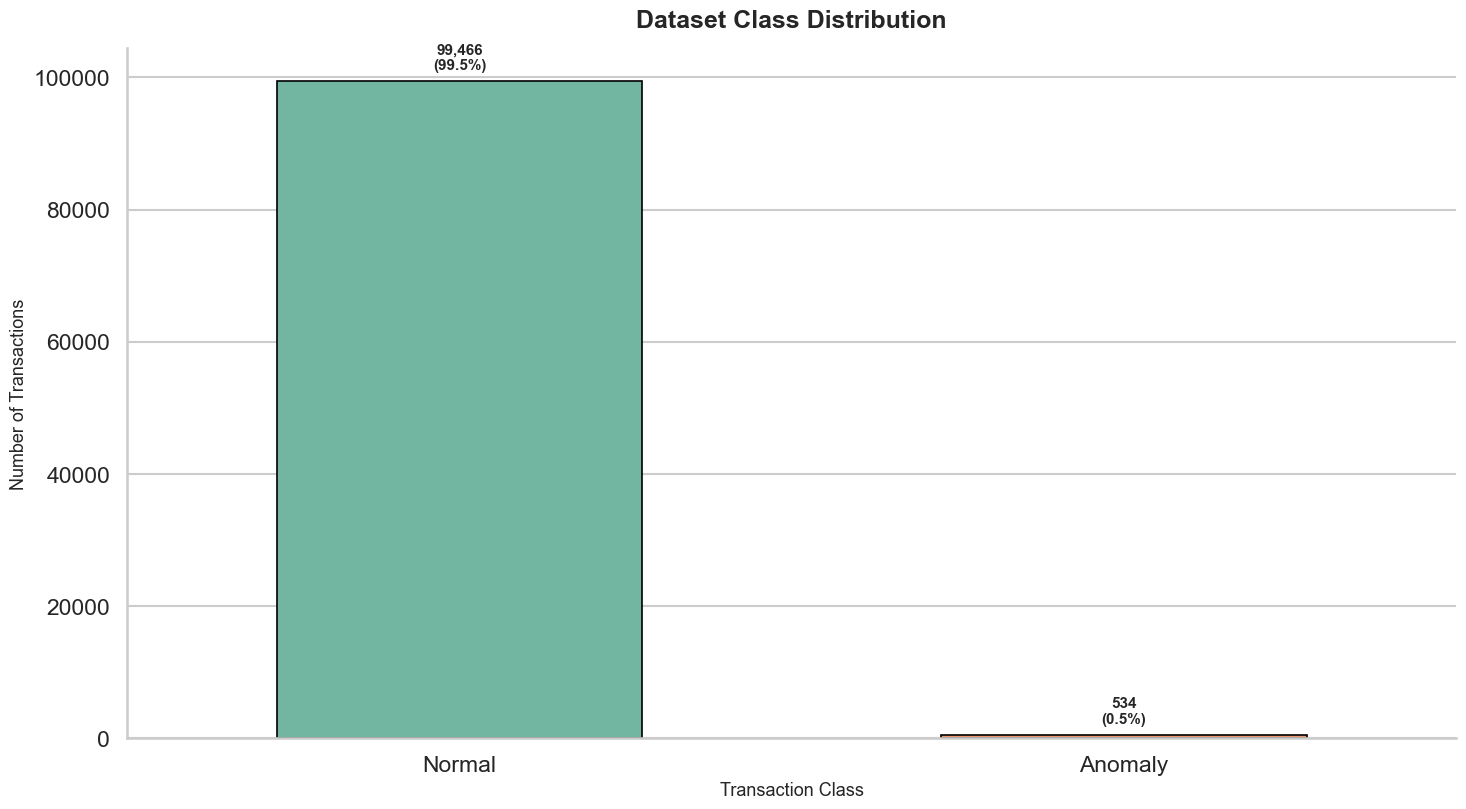

In [51]:
# ───────────────────────────────────────────────────────────────────────────
# EDA 1 — Dataset Class Distribution
# ───────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
plot = sns.countplot(
    data=df,
    x="anomaly_label",
    palette="Set2",
    width=0.55,
    edgecolor="black",
    linewidth=1.2,
)
plot.set_xticklabels(["Normal", "Anomaly"])
plt.title("Dataset Class Distribution", fontsize=18, weight="bold", pad=15)
plt.xlabel("Transaction Class", fontsize=13)
plt.ylabel("Number of Transactions", fontsize=13)

total_n = len(df)
for p in plot.patches:
    count = int(p.get_height())
    percent = 100 * count / total_n
    plot.annotate(
        f"{count:,}\n({percent:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        xytext=(0, 6),
        textcoords="offset points",
    )

sns.despine()
plt.tight_layout()
plt.show()

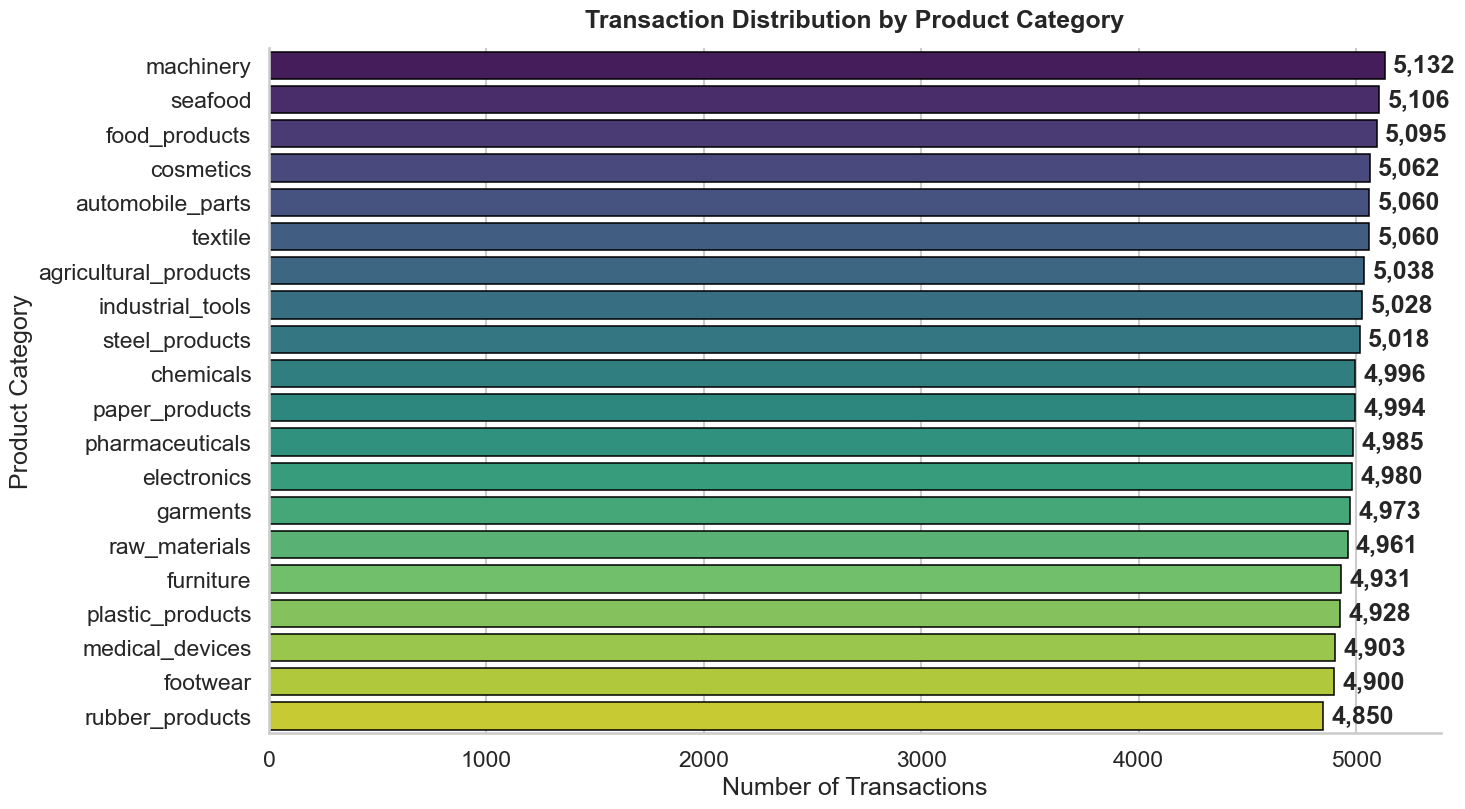

In [52]:
# ───────────────────────────────────────────────────────────────────────────
# EDA 2 — Product Category Distribution
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
ax = sns.countplot(
    data=df,
    y="product_group",
    order=df["product_group"].value_counts().index,
    palette="viridis",
    edgecolor="black",
    linewidth=1.1,
)
plt.title("Transaction Distribution by Product Category", weight="bold", pad=15)
plt.xlabel(
    "Number of Transactions",
)
plt.ylabel(
    "Product Category",
)

for p in ax.patches:
    width = int(p.get_width())
    ax.annotate(
        f"{width:,}",
        (width, p.get_y() + p.get_height() / 2),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontweight="bold",
    )

sns.despine(left=False)
plt.tight_layout()
plt.show()

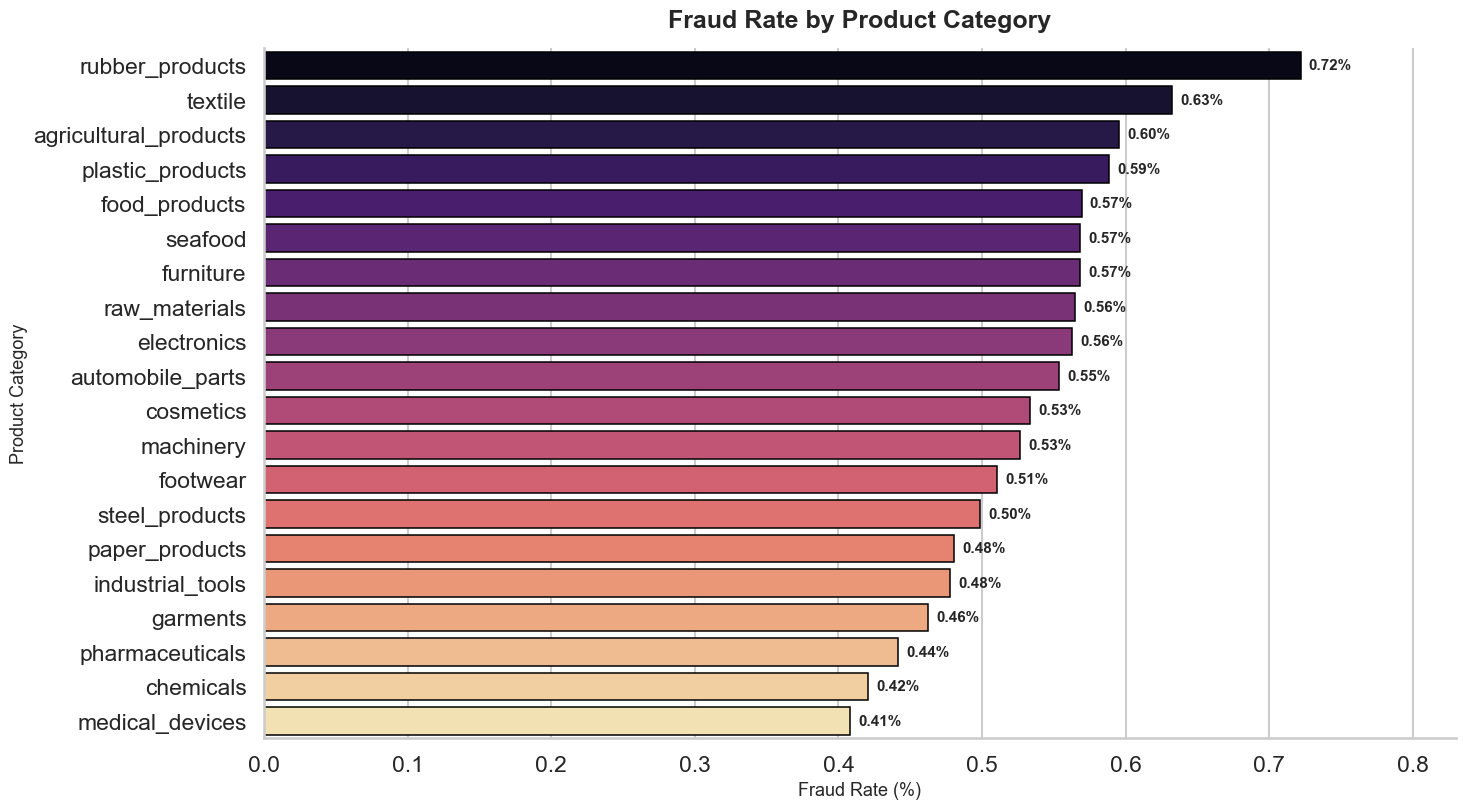

In [53]:
# ───────────────────────────────────────────────────────────────────────────
# EDA 3 — Fraud Rate by Product Category
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
fraud_rate = (
    df.groupby("product_group")["anomaly_label"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="fraud_rate")
)

ax = sns.barplot(
    data=fraud_rate,
    y="product_group",
    x="fraud_rate",
    palette="magma",
    edgecolor="black",
    linewidth=1.1,
)
plt.title("Fraud Rate by Product Category", fontsize=18, weight="bold", pad=15)
plt.xlabel("Fraud Rate (%)", fontsize=13)
plt.ylabel("Product Category", fontsize=13)

for p in ax.patches:
    value = p.get_width()
    ax.annotate(
        f"{value:.2f}%",
        (value, p.get_y() + p.get_height() / 2),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

ax.set_xlim(0, fraud_rate["fraud_rate"].max() * 1.15)
sns.despine(left=False)
plt.tight_layout()
plt.show()

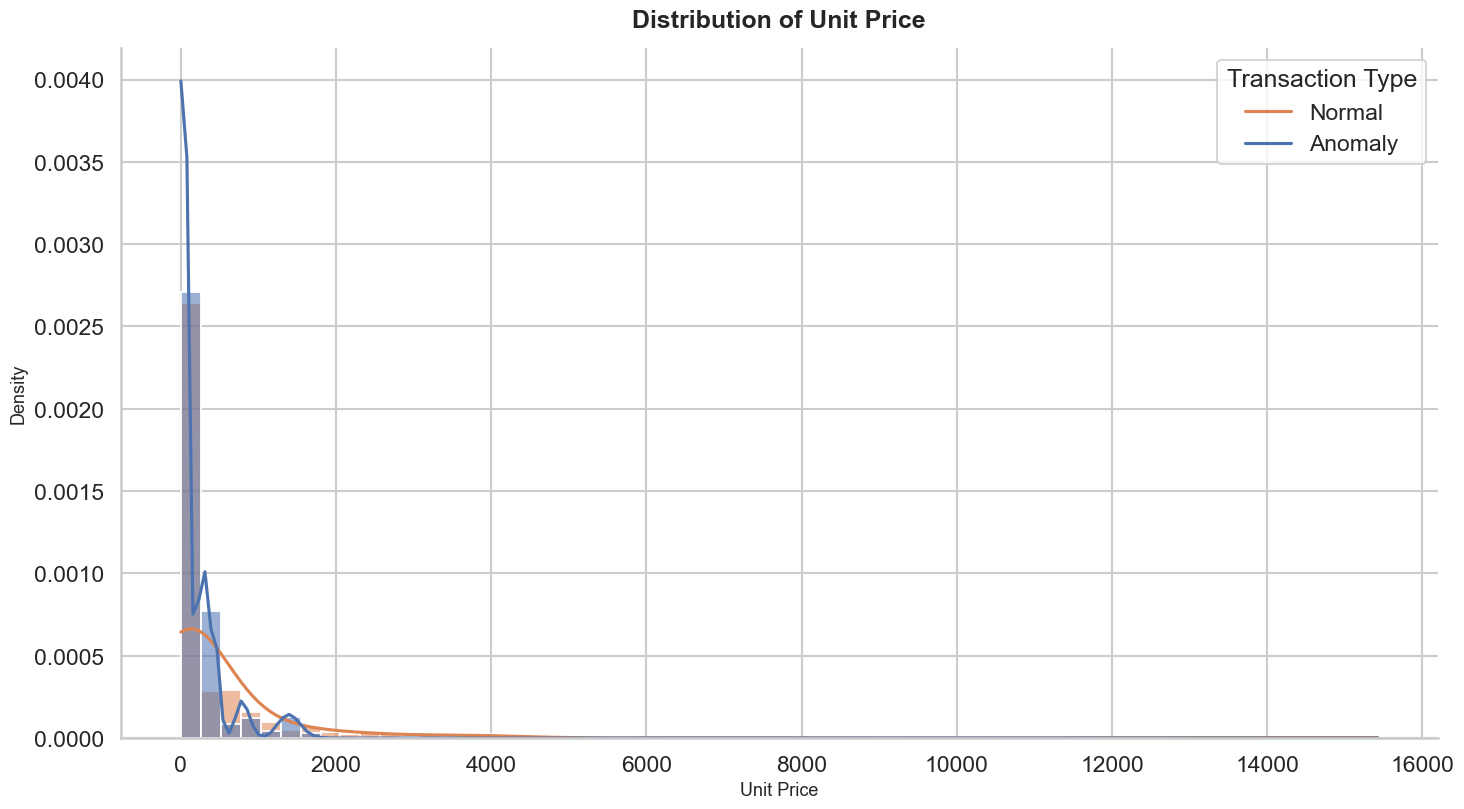

In [54]:
# ───────────────────────────────────────────────────────────────────────────
# EDA 4 — Unit Price Distribution by Class
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
sns.histplot(
    data=df,
    x="unit_price",
    hue="anomaly_label",
    bins=60,
    stat="density",
    common_norm=False,
    kde=True,
    palette=["#4C72B0", "#DD8452"],
    alpha=0.55,
    edgecolor=None,
)
plt.title("Distribution of Unit Price", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Unit Price", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.legend(title="Transaction Type", labels=["Normal", "Anomaly"], frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

In [20]:
# ═══════════════════════════════════════════════════════════════════════════
#  Feature Engineering (statistics learned from TRAIN split only)
# ═══════════════════════════════════════════════════════════════════════════

train_df = df[df["split"] == "train"]

# Peer median & MAD — computed from train, mapped to everyone
peer_median_map = train_df.groupby("hs_code")["unit_price"].median()

peer_mad_map = train_df.groupby("hs_code")["unit_price"].apply(
    lambda x: (x - x.median()).abs().median()
)

df["peer_median"] = df["hs_code"].map(peer_median_map)
df["MAD"] = df["hs_code"].map(peer_mad_map)

df["robust_z"] = (df["unit_price"] - df["peer_median"]) / (df["MAD"] + 1e-9)
df["abs_robust_z"] = df["robust_z"].abs()

df["price_ratio"] = df["unit_price"] / (df["peer_median"] + 1e-9)
df["log_price_ratio"] = np.log1p(np.abs(df["price_ratio"] - 1))

# Value anomaly — mean/std from train only
value_mean = train_df["declared_value"].mean()
value_std = train_df["declared_value"].std()
df["value_zscore"] = (df["declared_value"] - value_mean) / value_std

# Quantity anomaly — mean/std from train only
df["log_qty"] = np.log1p(df["quantity"])
qty_mean = np.log1p(train_df["quantity"]).mean()
qty_std = np.log1p(train_df["quantity"]).std()
df["qty_zscore"] = (df["log_qty"] - qty_mean) / qty_std

# Importer frequency — counted from train only
freq_map = train_df["importer_id"].value_counts()
df["importer_freq"] = df["importer_id"].map(freq_map).fillna(0)

FEATURES = [
    "robust_z",
    "value_zscore",
    "qty_zscore",
    "importer_freq",
    "country_risk",
]

# Scaler fit on TRAIN only, then applied to everyone
scaler = StandardScaler()
X_scaled = np.zeros((len(df), len(FEATURES)))
X_scaled[train_mask] = scaler.fit_transform(df.loc[train_mask, FEATURES].fillna(0))
X_scaled[val_mask] = scaler.transform(df.loc[val_mask, FEATURES].fillna(0))
X_scaled[test_mask] = scaler.transform(df.loc[test_mask, FEATURES].fillna(0))

print(f"Features engineered : {len(FEATURES)}")
print(f"Feature list         : {FEATURES}")

Features engineered : 5
Feature list         : ['robust_z', 'value_zscore', 'qty_zscore', 'importer_freq', 'country_risk']


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
#  Statistical Detector — Robust Z-score
# ═══════════════════════════════════════════════════════════════════════════

stat_score = min_max_scale(df["abs_robust_z"].values)

# Price ratio signal — a secondary, complementary price-deviation signal
ratio_signal = min_max_scale(df["log_price_ratio"].values)

print(f"stat_score   range : [{stat_score.min():.3f}, {stat_score.max():.3f}]")
print(f"ratio_signal range : [{ratio_signal.min():.3f}, {ratio_signal.max():.3f}]")

stat_score   range : [0.000, 1.000]
ratio_signal range : [0.000, 1.000]


In [22]:
# ═══════════════════════════════════════════════════════════════════════════
#  Isolation Forest — Contamination Selected via Train-Only Average Precision
# ═══════════════════════════════════════════════════════════════════════════

CONTAMINATION_GRID = np.arange(0.005, 0.055, 0.005)

best_ap_iso, best_contam, best_iso_forest = -1.0, None, None
iso_score = None

for c_val in CONTAMINATION_GRID:
    candidate_forest = IsolationForest(
        n_estimators=300,
        contamination=c_val,
        max_samples="auto",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    candidate_forest.fit(X_scaled[train_mask])
    candidate_score = min_max_scale(-candidate_forest.decision_function(X_scaled))

    ap_val = average_precision_score(y[val_mask], candidate_score[val_mask])

    if ap_val > best_ap_iso:
        best_ap_iso = ap_val
        best_contam = c_val
        best_iso_forest = candidate_forest
        iso_score = candidate_score

print(f"Selected contamination : {best_contam:.3f}  (val AP = {best_ap_iso:.4f})")

# Save train-derived normalization ranges (used later for the interactive
# predictor in the Appendix, so unseen inputs are normalized consistently)
STAT_RAW_MIN = df.loc[train_mask, "abs_robust_z"].min()
STAT_RAW_MAX = df.loc[train_mask, "abs_robust_z"].max()

ISO_RAW_TRAIN = -best_iso_forest.decision_function(X_scaled[train_mask])
ISO_RAW_MIN = ISO_RAW_TRAIN.min()
ISO_RAW_MAX = ISO_RAW_TRAIN.max()

RATIO_RAW_MIN = df.loc[train_mask, "log_price_ratio"].min()
RATIO_RAW_MAX = df.loc[train_mask, "log_price_ratio"].max()

Selected contamination : 0.005  (val AP = 0.1848)


In [23]:
# ═══════════════════════════════════════════════════════════════════════════
#  Ensemble Weights — learned from TRAIN-only Average Precision
# ═══════════════════════════════════════════════════════════════════════════

WEIGHT_STEP = 0.05
best_ap, best_weights = -1.0, None
ensemble_score = None

for a in np.arange(0.0, 1.0 + WEIGHT_STEP, WEIGHT_STEP):
    for b in np.arange(0.0, 1.0 - a + WEIGHT_STEP, WEIGHT_STEP):
        c = round(1.0 - a - b, 4)
        if c < 0:
            continue

        candidate_score = (stat_score**a) * (iso_score**b) * (ratio_signal**c)
        candidate_score = min_max_scale(candidate_score)

        ap_val = average_precision_score(y[val_mask], candidate_score[val_mask])

        if ap_val > best_ap:
            best_ap = ap_val
            best_weights = (round(a, 2), round(b, 2), c)
            ensemble_score = candidate_score

a_opt, b_opt, c_opt = best_weights
print(f"Learned weights (val AP = {best_ap:.4f}):")
print(f"  stat exponent  (a) = {a_opt}")
print(f"  iso exponent   (b) = {b_opt}")
print(f"  ratio exponent (c) = {c_opt}")

Learned weights (val AP = 0.9990):
  stat exponent  (a) = 0.55
  iso exponent   (b) = 0.0
  ratio exponent (c) = 0.45


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
#  Decision Threshold — F2-maximizing percentile, VAL-only
#  (F2 weights recall 4x more than precision — appropriate for AML/TBML,
#  where missing real fraud is costlier than an extra manual review)
# ═══════════════════════════════════════════════════════════════════════════

best_f2, best_thr = 0.0, 0.0
for pct in np.arange(85.0, 99.5, 0.1):
    thr = np.percentile(ensemble_score[val_mask], pct)
    pred_val = (ensemble_score[val_mask] >= thr).astype(int)
    f2 = fbeta_score(y[val_mask], pred_val, beta=2, zero_division=0)
    if f2 > best_f2:
        best_f2, best_thr = f2, thr

pred = (ensemble_score >= best_thr).astype(int)

print(f"Selected decision threshold : {best_thr:.4f}  (val F2 = {best_f2:.4f})")

Selected decision threshold : 0.0637  (val F2 = 0.9763)


In [25]:
# ═══════════════════════════════════════════════════════════════════════════
#  Z_THRESHOLD — derived from TRAIN data (direction classification)
# ═══════════════════════════════════════════════════════════════════════════

Z_GRID = np.arange(1.0, 5.05, 0.1)
best_z_f1, Z_THRESHOLD = -1.0, None

true_dir_val = df.loc[val_mask, "true_direction"].values
robust_z_val = df.loc[val_mask, "robust_z"].values

for z_cut in Z_GRID:
    pred_dir = np.where(
        robust_z_val > z_cut,
        "OVER_INVOICING",
        np.where(robust_z_val < -z_cut, "UNDER_INVOICING", "NORMAL"),
    )
    score = f1_score(true_dir_val, pred_dir, average="macro", zero_division=0)
    if score > best_z_f1:
        best_z_f1, Z_THRESHOLD = score, z_cut

print(f"Derived Z_THRESHOLD : {Z_THRESHOLD:.2f}  (val macro-F1 = {best_z_f1:.4f})")

Derived Z_THRESHOLD : 5.00  (val macro-F1 = 0.9243)


In [26]:
# ═══════════════════════════════════════════════════════════════════════════
#  Direction Detection & Business Explanation
# ═══════════════════════════════════════════════════════════════════════════
def get_direction(z):
    if z > Z_THRESHOLD:
        return "OVER_INVOICING"
    elif z < -Z_THRESHOLD:
        return "UNDER_INVOICING"
    else:
        return "NORMAL"


df["ensemble_score"] = ensemble_score
df["ensemble_pred"] = pred
df["risk_level"] = pd.Series(pred).map({1: "HIGH", 0: "LOW"}).values
df["predicted_direction"] = df["robust_z"].apply(get_direction)


def explain(row):
    parts = []
    z = row["robust_z"]
    if abs(z) > Z_THRESHOLD:
        side = "above" if z > 0 else "below"
        parts.append(
            f"Unit price {abs(z):.1f}σ {side} peer median "
            f"→ {row['predicted_direction'].replace('_',' ').lower()}"
        )
    if row["ensemble_pred"] == 1 and abs(z) <= Z_THRESHOLD:
        parts.append("Multivariate pattern anomalous (Isolation Forest)")
    if row["country_risk"] == 1:
        parts.append("High-risk trade corridor")
    return " | ".join(parts) if parts else "No significant risk signals"


df["explanation"] = df.apply(explain, axis=1)

print("Direction and explanation columns generated.")
print(
    df[["txn_id", "risk_level", "predicted_direction", "explanation"]]
    .head(3)
    .to_string(index=False)
)

Direction and explanation columns generated.
  txn_id risk_level predicted_direction                 explanation
TXN00001        LOW              NORMAL    High-risk trade corridor
TXN00002        LOW              NORMAL    High-risk trade corridor
TXN00003        LOW              NORMAL No significant risk signals


In [27]:
# ═══════════════════════════════════════════════════════════════════════════
#  Evaluation Metrics (TEST split only)
# ═══════════════════════════════════════════════════════════════════════════

p = precision_score(y[test_mask], pred[test_mask], zero_division=0)
r = recall_score(y[test_mask], pred[test_mask], zero_division=0)
f1 = f1_score(y[test_mask], pred[test_mask], zero_division=0)
f2 = fbeta_score(y[test_mask], pred[test_mask], beta=2, zero_division=0)
auc = roc_auc_score(y[test_mask], ensemble_score[test_mask])
ap = average_precision_score(y[test_mask], ensemble_score[test_mask])
ba = balanced_accuracy_score(y[test_mask], pred[test_mask])
cm = confusion_matrix(y[test_mask], pred[test_mask])
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fn_r = fn / y[test_mask].sum()

print("=" * 60)
print("  EVALUATION RESULTS (Test Split)")
print("=" * 60)
print(f"  TP = {tp:4d}  (real fraud caught)")
print(f"  FP = {fp:4d}  (false alarms)")
print(f"  TN = {tn:4d}  (normal correctly passed)")
print(f"  FN = {fn:4d}  (fraud missed)")
print("-" * 60)

METRICS = [
    ("Precision", p),
    ("Recall", r),
    ("F1-Score", f1),
    ("F2-Score", f2),
    ("AUC-ROC", auc),
    ("Avg Precision", ap),
    ("Balanced Acc.", ba),
    ("FPR", fpr),
    ("FN rate", fn_r),
]
for name, val in METRICS:
    print(f"  {name:<20} {val*100:>7.2f}%")

print("=" * 60)
print("\nClassification Report:")
print(
    classification_report(
        y[test_mask], pred[test_mask], target_names=["Normal", "Suspicious"], digits=3
    )
)

  EVALUATION RESULTS (Test Split)
  TP =  107  (real fraud caught)
  FP =   27  (false alarms)
  TN = 19866  (normal correctly passed)
  FN =    0  (fraud missed)
------------------------------------------------------------
  Precision              79.85%
  Recall                100.00%
  F1-Score               88.80%
  F2-Score               95.20%
  AUC-ROC               100.00%
  Avg Precision          99.92%
  Balanced Acc.          99.93%
  FPR                     0.14%
  FN rate                 0.00%

Classification Report:
              precision    recall  f1-score   support

      Normal      1.000     0.999     0.999     19893
  Suspicious      0.799     1.000     0.888       107

    accuracy                          0.999     20000
   macro avg      0.899     0.999     0.944     20000
weighted avg      0.999     0.999     0.999     20000



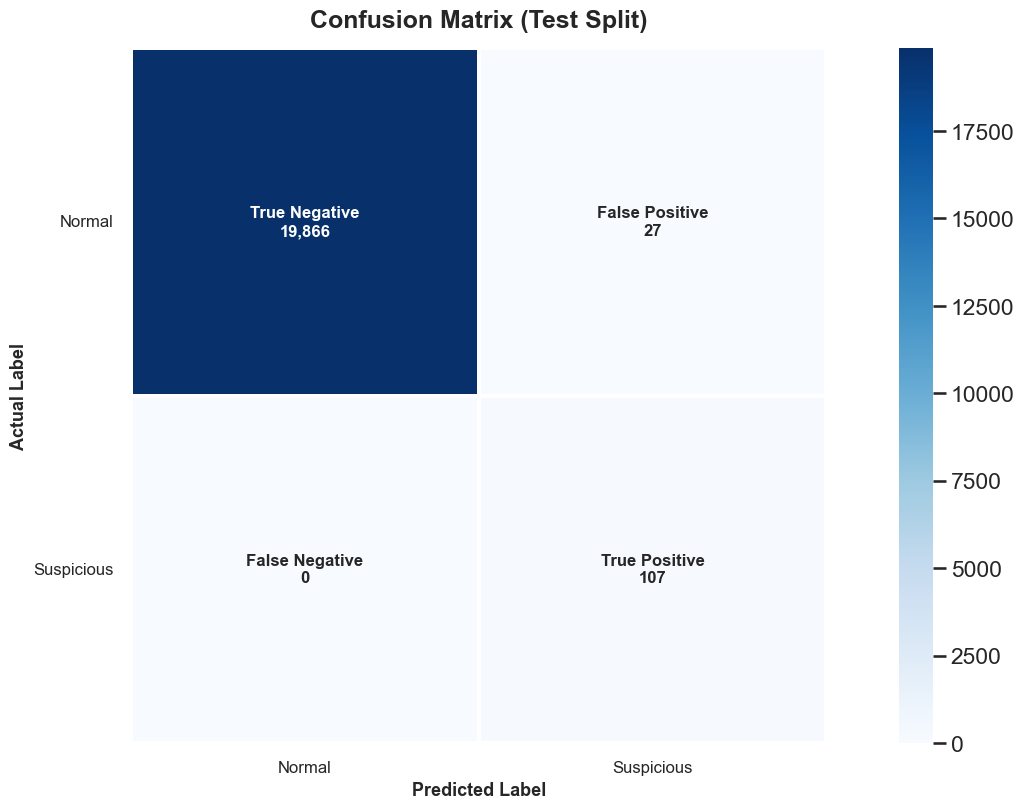

In [55]:
# ───────────────────────────────────────────────────────────────────────────
# Confusion Matrix
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
cm = confusion_matrix(y[test_mask], pred[test_mask])
labels = np.array(
    [
        [f"True Negative\n{cm[0,0]:,}", f"False Positive\n{cm[0,1]:,}"],
        [f"False Negative\n{cm[1,0]:,}", f"True Positive\n{cm[1,1]:,}"],
    ]
)

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={"fontsize": 12, "fontweight": "bold"},
)
plt.title("Confusion Matrix (Test Split)", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Predicted Label", fontsize=13, fontweight="bold")
plt.ylabel("Actual Label", fontsize=13, fontweight="bold")
plt.gca().set_xticklabels(["Normal", "Suspicious"], fontsize=12)
plt.gca().set_yticklabels(["Normal", "Suspicious"], fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

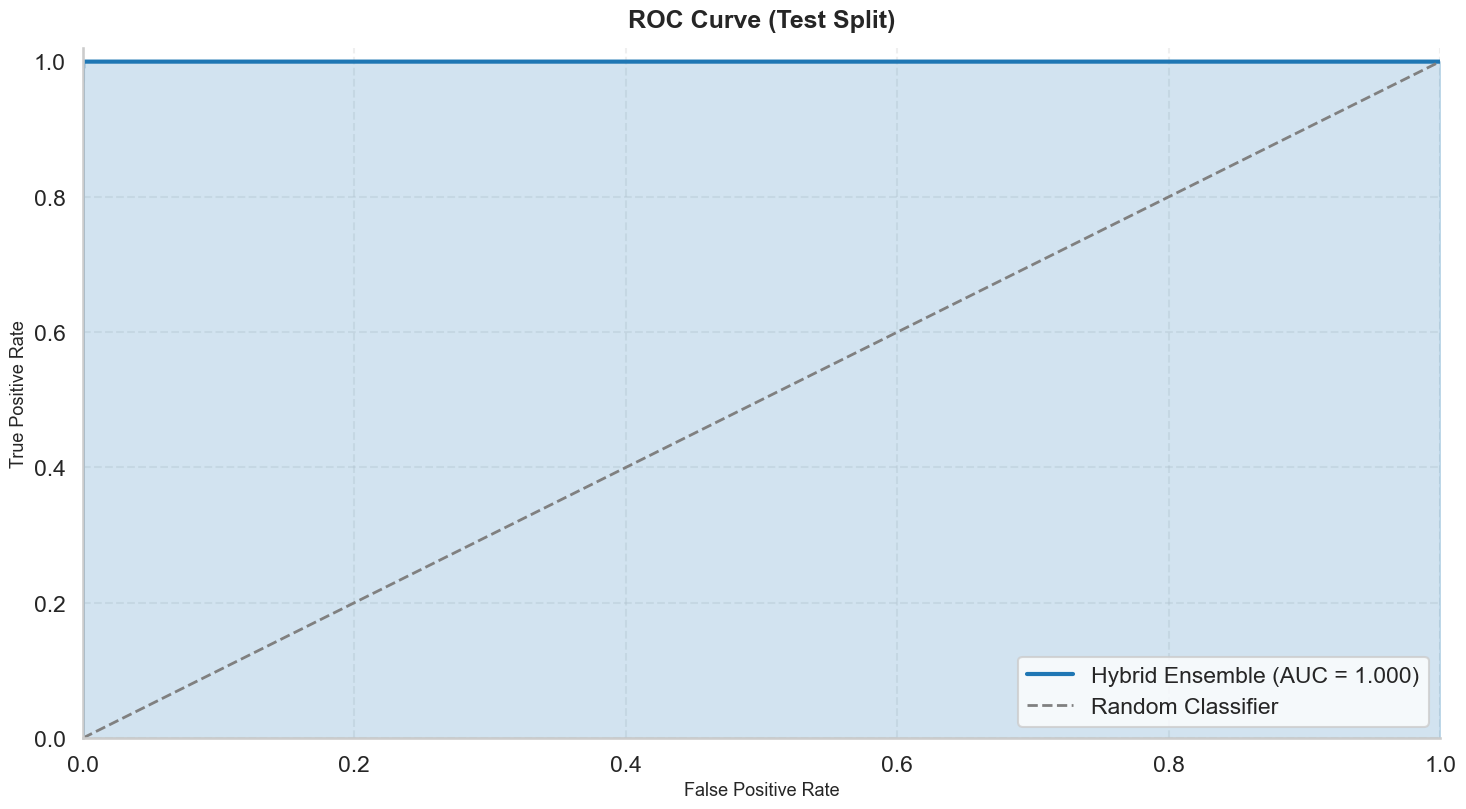

In [56]:
# ───────────────────────────────────────────────────────────────────────────
# ROC Curve
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
fpr_curve, tpr_curve, _ = roc_curve(y[test_mask], ensemble_score[test_mask])

plt.plot(
    fpr_curve,
    tpr_curve,
    color="#1f77b4",
    linewidth=3,
    label=f"Hybrid Ensemble (AUC = {auc:.3f})",
)
plt.fill_between(fpr_curve, tpr_curve, alpha=0.20, color="#1f77b4")
plt.plot(
    [0, 1], [0, 1], linestyle="--", color="gray", linewidth=2, label="Random Classifier"
)
plt.title("ROC Curve (Test Split)", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(alpha=0.30, linestyle="--")
plt.legend(loc="lower right", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

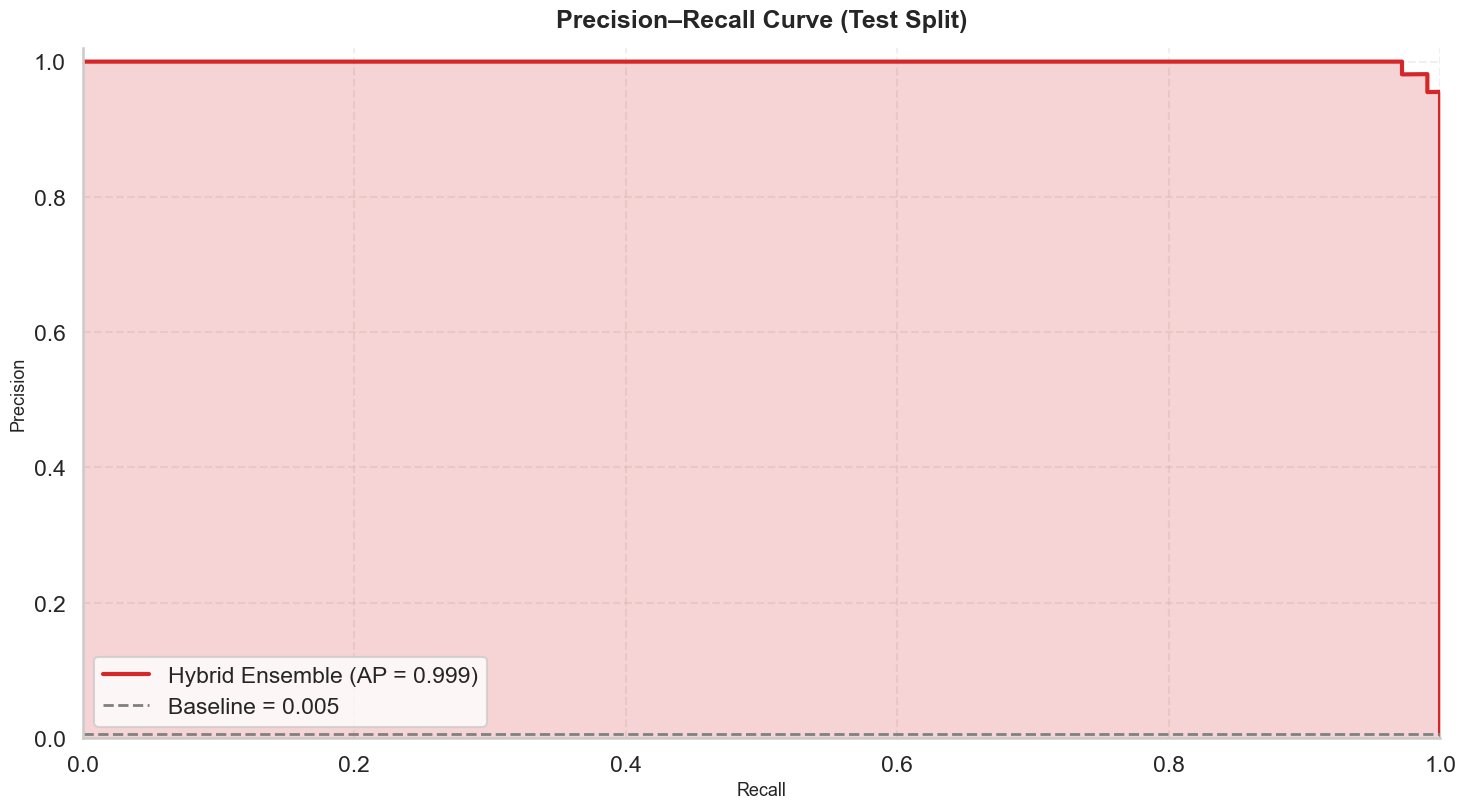

In [57]:
# ───────────────────────────────────────────────────────────────────────────
# Precision-Recall Curve
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
precision_curve, recall_curve, _ = precision_recall_curve(
    y[test_mask], ensemble_score[test_mask]
)
baseline = y[test_mask].mean()

plt.plot(
    recall_curve,
    precision_curve,
    color="#D62728",
    linewidth=3,
    label=f"Hybrid Ensemble (AP = {ap:.3f})",
)
plt.fill_between(recall_curve, precision_curve, alpha=0.20, color="#D62728")
plt.axhline(
    baseline,
    color="gray",
    linestyle="--",
    linewidth=2,
    label=f"Baseline = {baseline:.3f}",
)
plt.title("Precision–Recall Curve (Test Split)", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Recall", fontsize=13)
plt.ylabel("Precision", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(alpha=0.30, linestyle="--")
plt.legend(loc="lower left", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

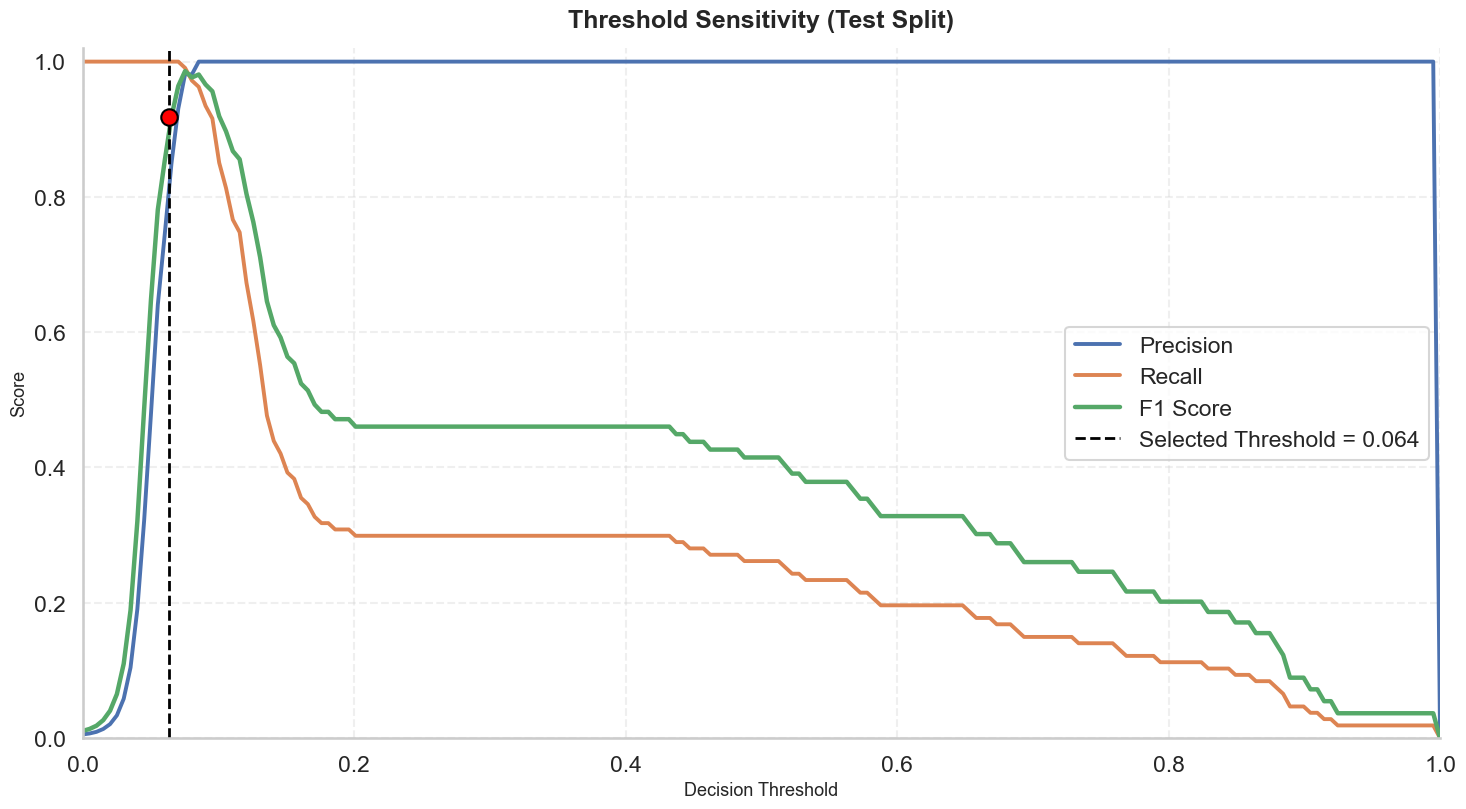

In [58]:
# ───────────────────────────────────────────────────────────────────────────
# Threshold Sensitivity (Test Split)
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
thresholds_plot = np.linspace(0, 1, 200)
precision_list, recall_list, f1_list = [], [], []

for thr in thresholds_plot:
    preds = (ensemble_score[test_mask] >= thr).astype(int)
    precision_list.append(precision_score(y[test_mask], preds, zero_division=0))
    recall_list.append(recall_score(y[test_mask], preds, zero_division=0))
    f1_list.append(f1_score(y[test_mask], preds, zero_division=0))

sns.lineplot(x=thresholds_plot, y=precision_list, linewidth=2.8, label="Precision")
sns.lineplot(x=thresholds_plot, y=recall_list, linewidth=2.8, label="Recall")
sns.lineplot(x=thresholds_plot, y=f1_list, linewidth=3.2, label="F1 Score")
plt.axvline(
    best_thr,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Selected Threshold = {best_thr:.3f}",
)

best_index = np.argmin(np.abs(thresholds_plot - best_thr))
plt.scatter(
    best_thr, f1_list[best_index], s=140, color="red", edgecolor="black", zorder=5
)

plt.title("Threshold Sensitivity (Test Split)", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Decision Threshold", fontsize=13)
plt.ylabel("Score", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(linestyle="--", alpha=0.3)
plt.legend(frameon=True, loc="best")
sns.despine()
plt.tight_layout()
plt.show()

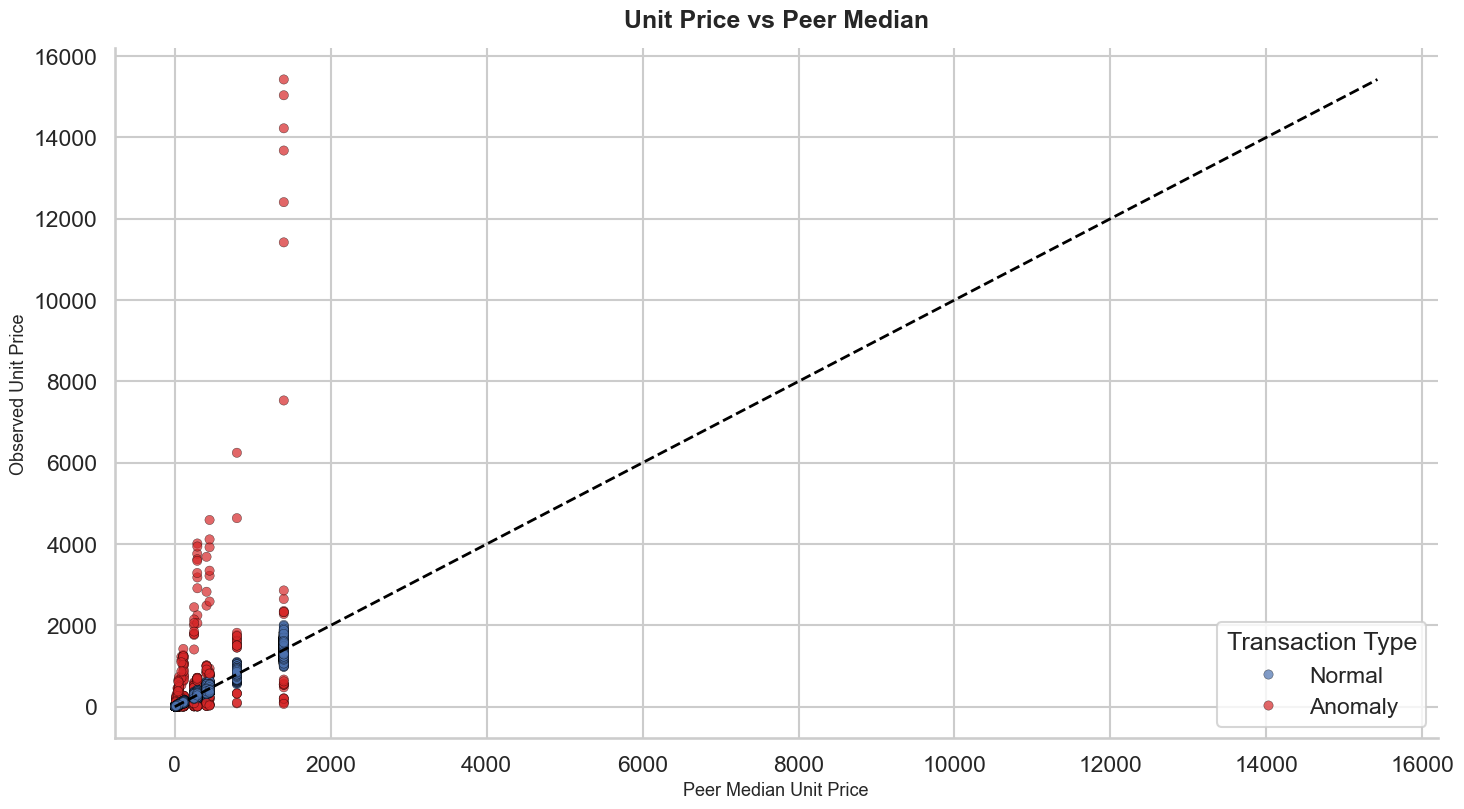

In [59]:
# ───────────────────────────────────────────────────────────────────────────
# Diagnostic 1 — Unit Price vs Peer Median
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
ax = sns.scatterplot(
    data=df,
    x="peer_median",
    y="unit_price",
    hue="anomaly_label",
    palette=["#4C72B0", "#D62728"],
    alpha=0.70,
    s=45,
    edgecolor="black",
    linewidth=0.3,
)
max_val = max(df["peer_median"].max(), df["unit_price"].max())
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    linewidth=2,
    color="black",
    label="Expected Price",
)
plt.title("Unit Price vs Peer Median", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Peer Median Unit Price", fontsize=13)
plt.ylabel("Observed Unit Price", fontsize=13)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Normal", "Anomaly"], title="Transaction Type", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

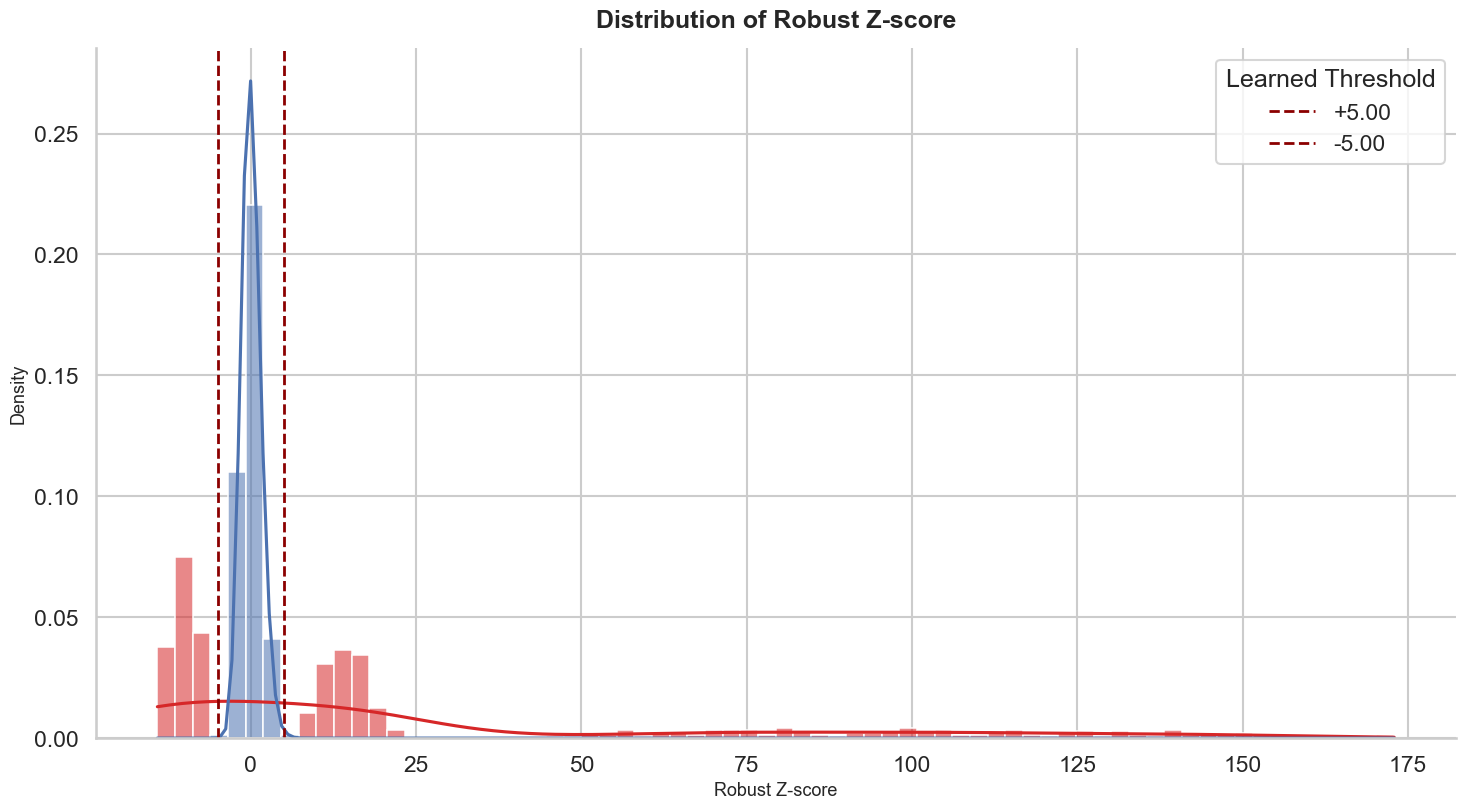

In [60]:
# ───────────────────────────────────────────────────────────────────────────
# Diagnostic 2 — Robust Z-score Distribution
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
sns.histplot(
    data=df,
    x="robust_z",
    hue="anomaly_label",
    bins=70,
    kde=True,
    stat="density",
    common_norm=False,
    palette=["#4C72B0", "#D62728"],
    alpha=0.55,
    edgecolor=None,
)
plt.axvline(
    x=Z_THRESHOLD,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"+{Z_THRESHOLD:.2f}",
)
plt.axvline(
    x=-Z_THRESHOLD,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"-{Z_THRESHOLD:.2f}",
)
plt.title("Distribution of Robust Z-score", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Robust Z-score", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.legend(title="Learned Threshold", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

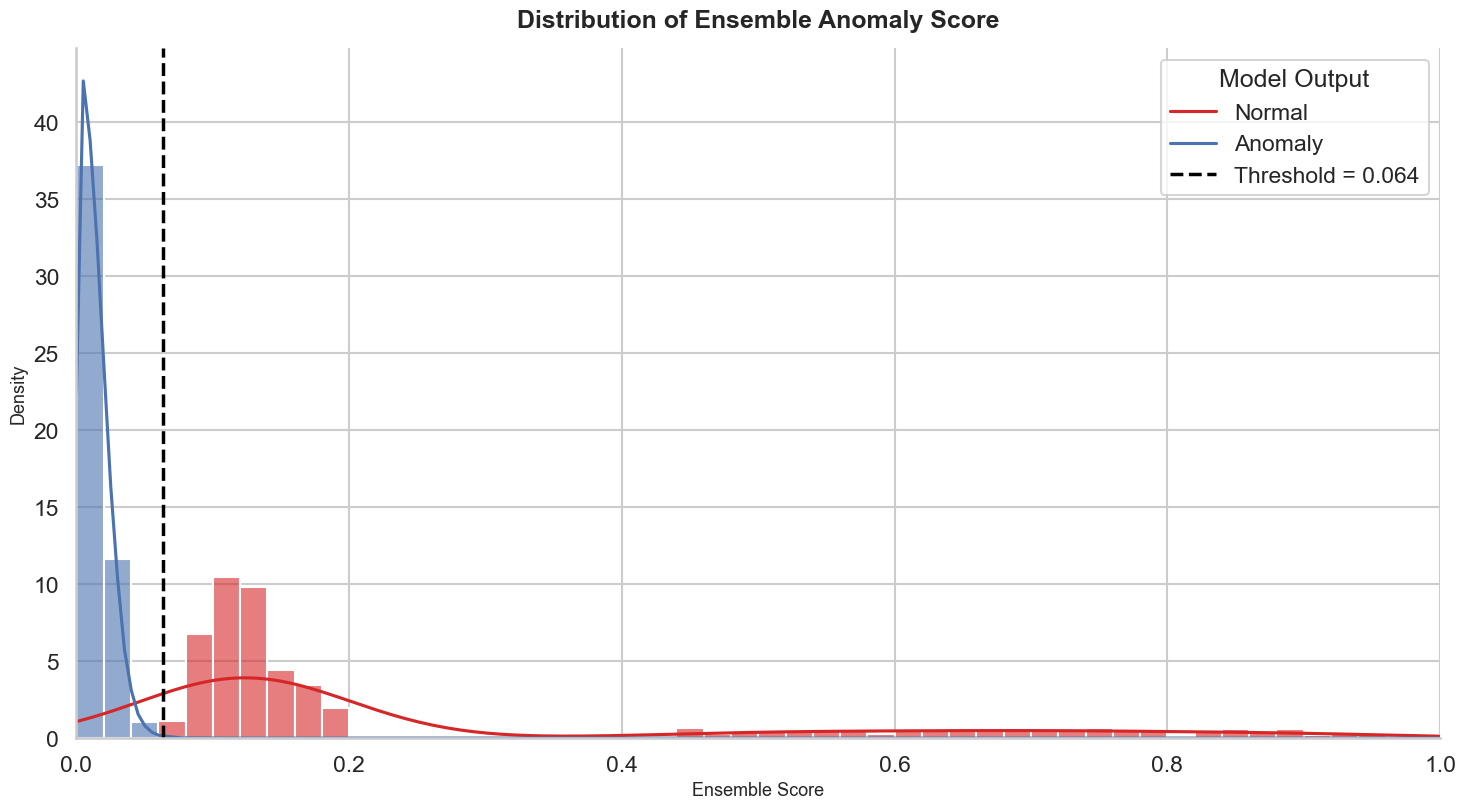

In [61]:
# ───────────────────────────────────────────────────────────────────────────
# Diagnostic 3 — Ensemble Score Distribution
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
sns.histplot(
    data=df,
    x="ensemble_score",
    hue="anomaly_label",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False,
    palette=["#4C72B0", "#D62728"],
    alpha=0.60,
    edgecolor=None,
)
plt.axvline(
    best_thr,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Decision Threshold = {best_thr:.3f}",
)
plt.title(
    "Distribution of Ensemble Anomaly Score", fontsize=18, fontweight="bold", pad=15
)
plt.xlabel("Ensemble Score", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.xlim(0, 1)
plt.legend(
    title="Model Output",
    labels=["Normal", "Anomaly", f"Threshold = {best_thr:.3f}"],
    frameon=True,
)
sns.despine()
plt.tight_layout()
plt.show()

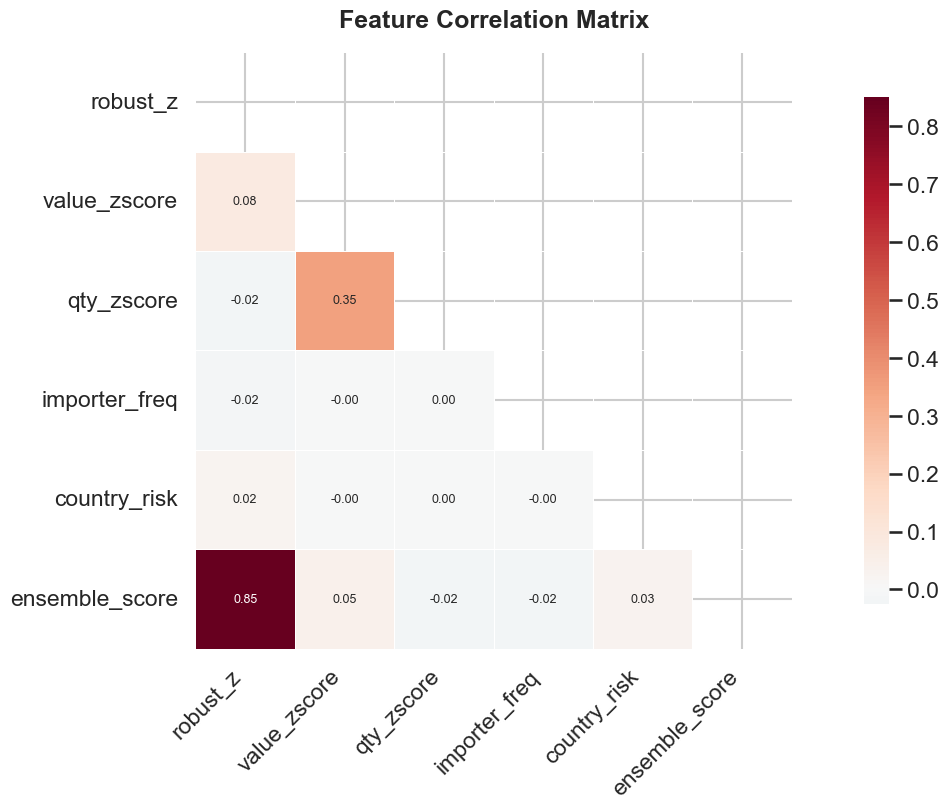

In [62]:
# ───────────────────────────────────────────────────────────────────────────
# Diagnostic 4 — Feature Correlation Heatmap
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
feature_cols_corr = FEATURES + ["ensemble_score"]
corr = df[feature_cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.85},
    annot_kws={"size": 9},
)
plt.title("Feature Correlation Matrix", fontsize=18, fontweight="bold", pad=18)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

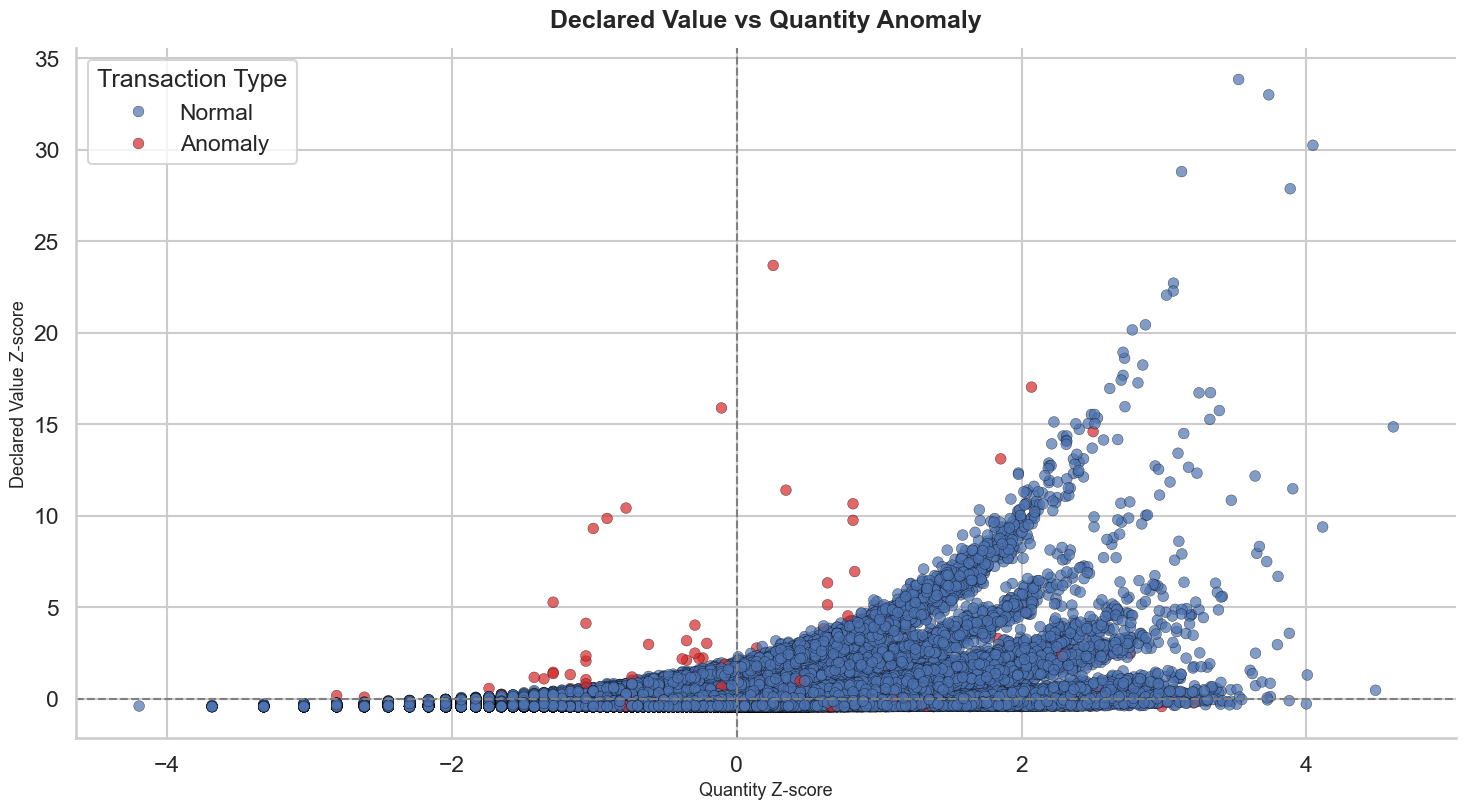

In [63]:
# ───────────────────────────────────────────────────────────────────────────
# Diagnostic 5 — Declared Value vs Quantity Anomaly
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
ax = sns.scatterplot(
    data=df,
    x="qty_zscore",
    y="value_zscore",
    hue="anomaly_label",
    palette=["#4C72B0", "#D62728"],
    alpha=0.70,
    s=60,
    edgecolor="black",
    linewidth=0.3,
)
plt.axhline(0, linestyle="--", color="gray", linewidth=1.5)
plt.axvline(0, linestyle="--", color="gray", linewidth=1.5)
plt.title("Declared Value vs Quantity Anomaly", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Quantity Z-score", fontsize=13)
plt.ylabel("Declared Value Z-score", fontsize=13)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Normal", "Anomaly"], title="Transaction Type", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

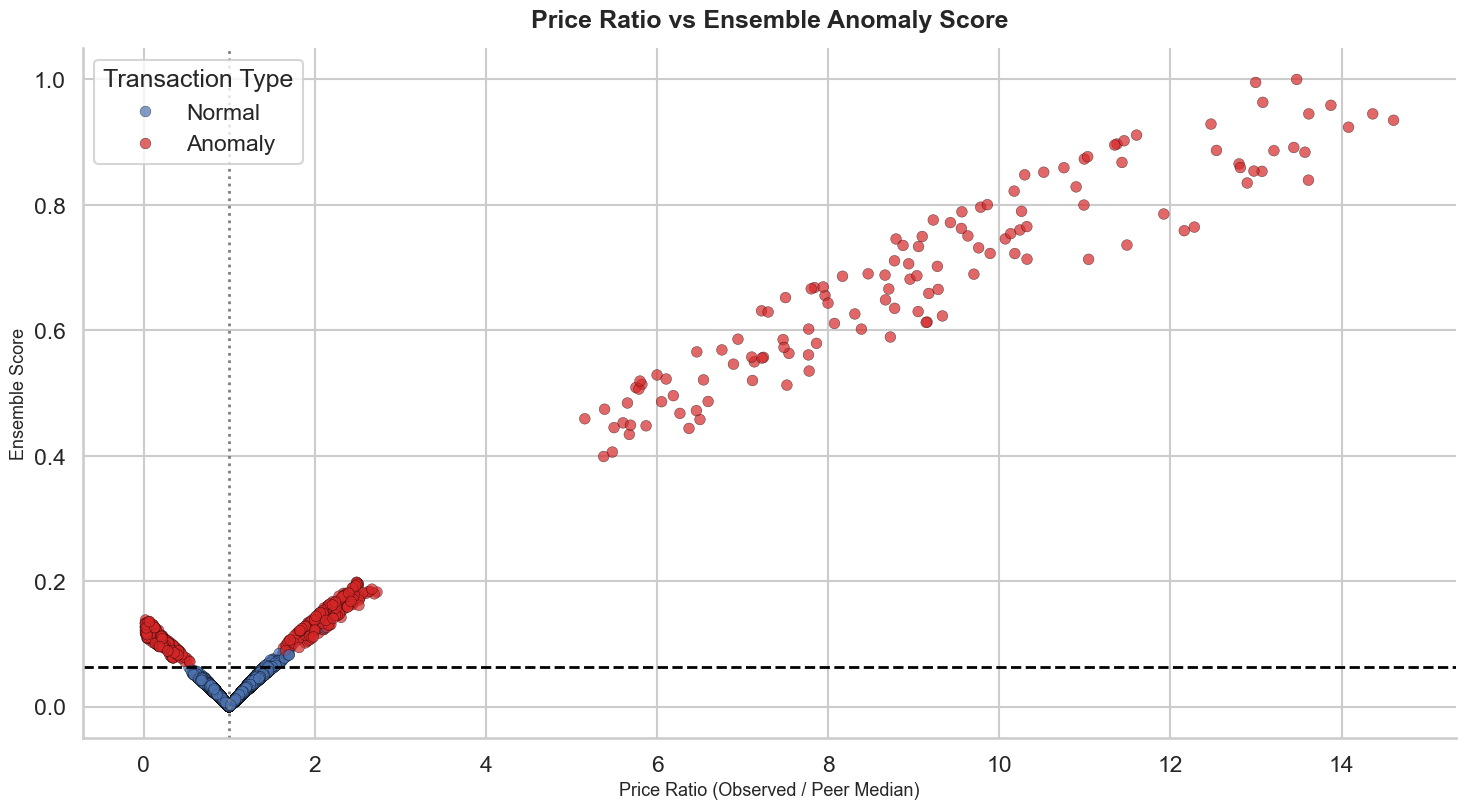

In [64]:
# ───────────────────────────────────────────────────────────────────────────
# Diagnostic 6 — Price Ratio vs Ensemble Score
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
ax = sns.scatterplot(
    data=df,
    x="price_ratio",
    y="ensemble_score",
    hue="anomaly_label",
    palette=["#4C72B0", "#D62728"],
    alpha=0.70,
    s=60,
    edgecolor="black",
    linewidth=0.3,
)
plt.axhline(
    y=best_thr,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_thr:.3f}",
)
plt.axvline(
    x=1.0, color="gray", linestyle=":", linewidth=2, label="Expected Price Ratio"
)
plt.title(
    "Price Ratio vs Ensemble Anomaly Score", fontsize=18, fontweight="bold", pad=15
)
plt.xlabel("Price Ratio (Observed / Peer Median)", fontsize=13)
plt.ylabel("Ensemble Score", fontsize=13)
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ["Normal", "Anomaly"],
    title="Transaction Type",
    frameon=True,
    loc="upper left",
)
sns.despine()
plt.tight_layout()
plt.show()

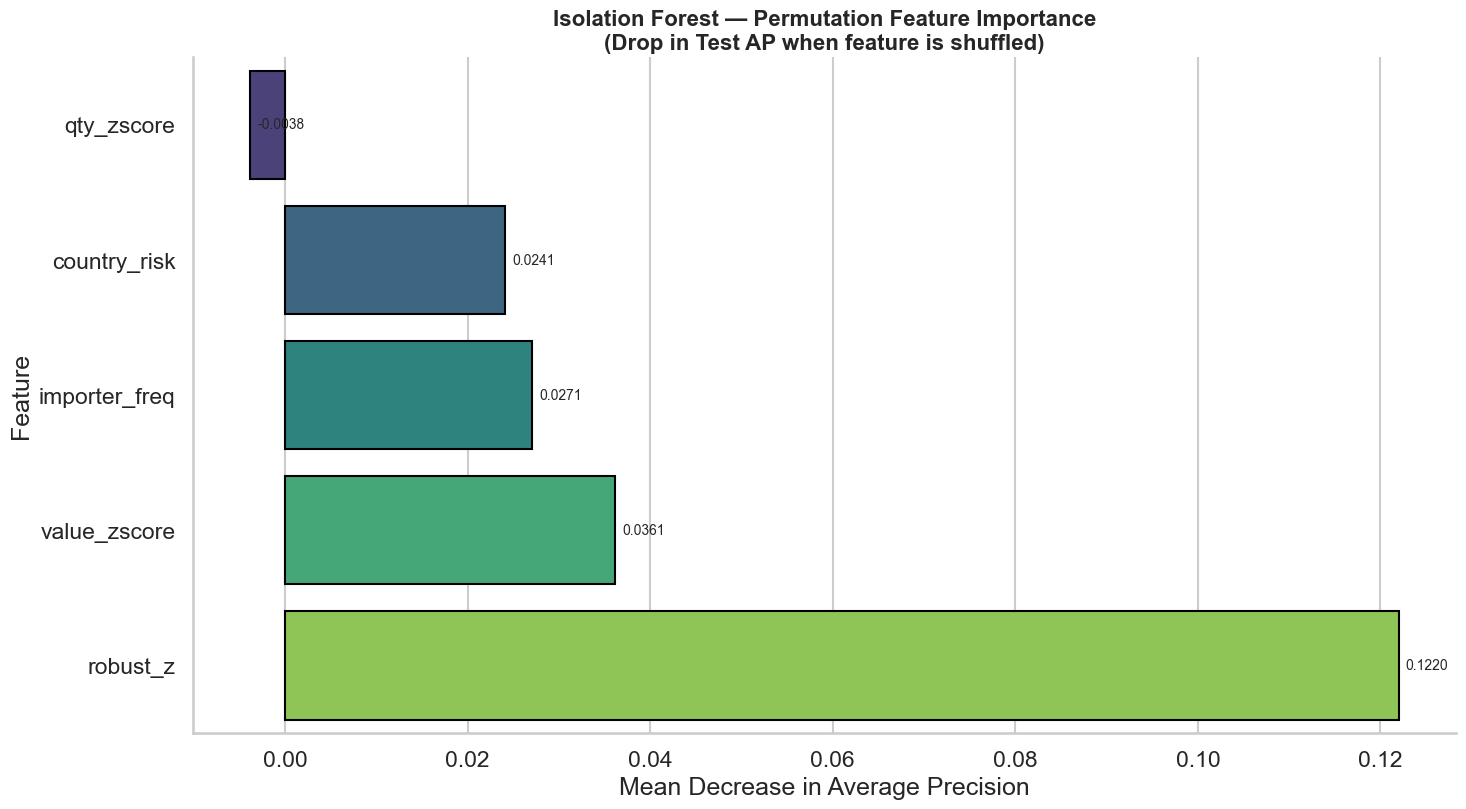

{'importances_mean': array([ 0.12199438,  0.03613941, -0.00382936,  0.02709547,  0.02413598]), 'importances_std': array([0.00083578, 0.01147559, 0.00737524, 0.01138548, 0.00516904]), 'importances': array([[ 0.12171404,  0.12004657,  0.12097803,  0.12172405,  0.122834  ,
         0.12239681,  0.12126003,  0.12235002,  0.12022487,  0.12218052,
         0.12309541,  0.12229373,  0.12287914,  0.12307398,  0.12213706,
         0.12274783,  0.12203213,  0.1221736 ,  0.12143014,  0.12231566],
       [ 0.0524659 ,  0.04102802,  0.05300336,  0.03510324,  0.01461487,
         0.02130454,  0.046203  ,  0.02740907,  0.02018654,  0.04291213,
         0.04039217,  0.03756605,  0.04796376,  0.02689758,  0.03640102,
         0.03886034,  0.02766344,  0.05700807,  0.02728206,  0.02852293],
       [-0.02047368,  0.00170464, -0.00287153,  0.00317193,  0.00392998,
         0.01115233, -0.00518009, -0.00174619,  0.00500166, -0.00075648,
         0.00322111, -0.00616663, -0.01006405, -0.00703581, -0.0089689

In [ ]:
# ───────────────────────────────────────────────────────────────────────────
# Diagnostic 7 — Isolation Forest Permutation Importance (non-circular)
# ───────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))


def iso_forest_ap_scorer(estimator, X, y_true):
    raw_score = -estimator.decision_function(X)
    return average_precision_score(y_true, raw_score)


perm_result = permutation_importance(
    best_iso_forest,
    X_scaled[test_mask],
    y[test_mask],
    scoring=iso_forest_ap_scorer,
    n_repeats=20,
    random_state=RANDOM_SEED,
)

perm_importance = pd.Series(perm_result.importances_mean, index=FEATURES).sort_values()

ax = sns.barplot(
    x=perm_importance.values,
    y=perm_importance.index,
    palette="viridis",
    edgecolor="black",
)
for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.4f}",
        (p.get_width(), p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
    )
plt.title(
    "Isolation Forest — Permutation Feature Importance\n(Drop in Test AP when feature is shuffled)",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Mean Decrease in Average Precision")
plt.ylabel("Feature")
sns.despine()
plt.tight_layout()
plt.show()
print(perm_result)

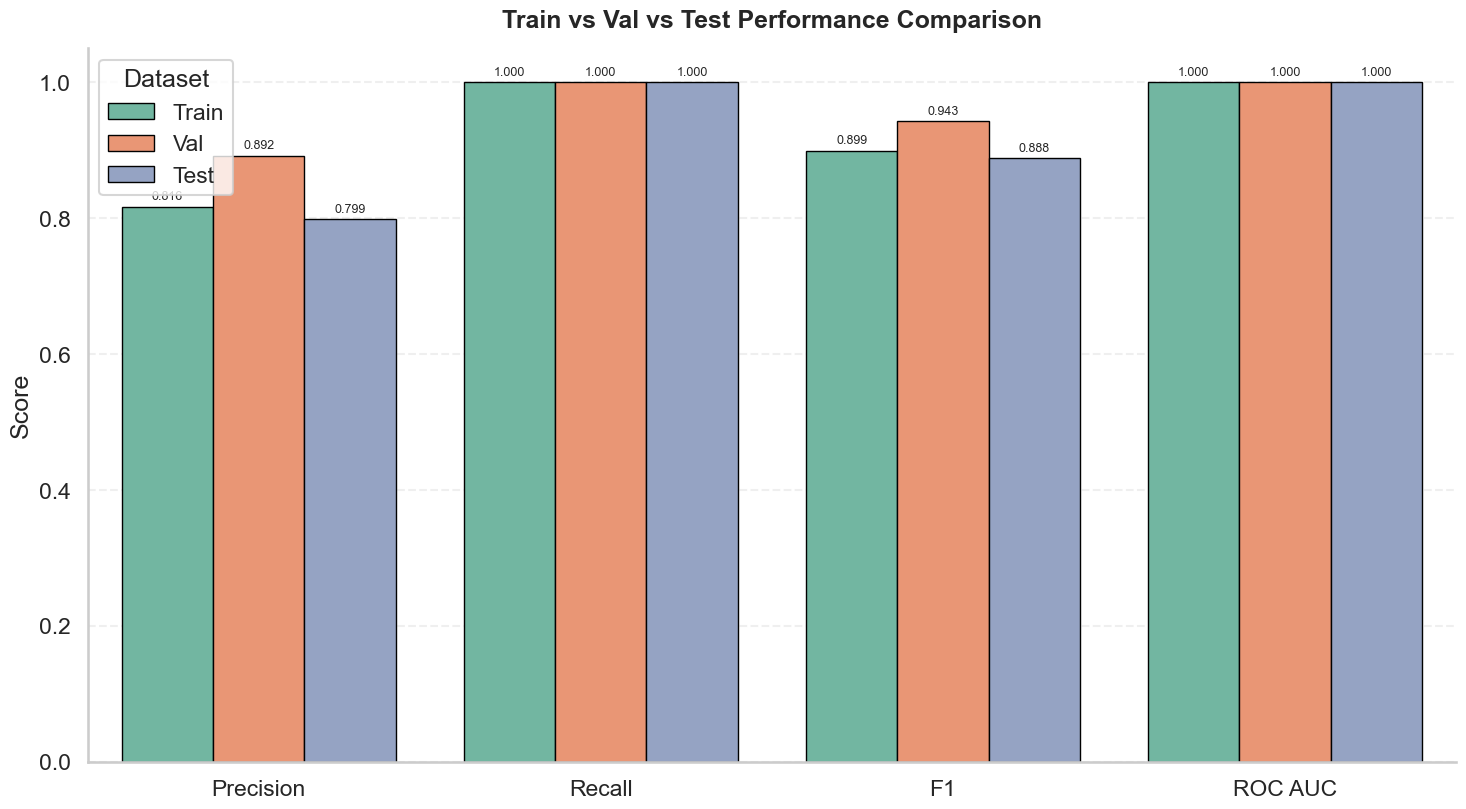

In [66]:
# ───────────────────────────────────────────────────────────────────────────
# Diagnostic 8 — Train vs Val vs Test Performance (overfitting check)
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
train_pred = (ensemble_score[train_mask] >= best_thr).astype(int)
val_pred = (ensemble_score[val_mask] >= best_thr).astype(int)
test_pred = (ensemble_score[test_mask] >= best_thr).astype(int)


def _metrics(y_true, y_pred, score):
    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, score),
    }


train_metrics = _metrics(y[train_mask], train_pred, ensemble_score[train_mask])
val_metrics = _metrics(y[val_mask], val_pred, ensemble_score[val_mask])
test_metrics = _metrics(y[test_mask], test_pred, ensemble_score[test_mask])

metrics_df = pd.DataFrame(
    {
        "Metric": train_metrics.keys(),
        "Train": train_metrics.values(),
        "Val": val_metrics.values(),
        "Test": test_metrics.values(),
    }
)
metrics_long = metrics_df.melt(id_vars="Metric", var_name="Dataset", value_name="Score")

ax = sns.barplot(
    data=metrics_long,
    x="Metric",
    y="Score",
    hue="Dataset",
    palette="Set2",
    edgecolor="black",
    linewidth=1,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=3)
plt.title(
    "Train vs Val vs Test Performance Comparison",
    fontsize=18,
    fontweight="bold",
    pad=15,
)
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

In [40]:
# ═══════════════════════════════════════════════════════════════════════════
#  Transaction-level Explanation
# ═══════════════════════════════════════════════════════════════════════════

df["stat_score"] = stat_score
df["iso_score"] = iso_score
df["ratio_signal"] = ratio_signal


def explain_transaction(index: int):
    row = df.loc[index]

    components = {
        "Statistical Detector": row["stat_score"] ** a_opt,
        "Isolation Forest": row["iso_score"] ** b_opt,
        "Price Ratio Signal": row["ratio_signal"] ** c_opt,
    }
    total = sum(components.values())
    contribution = {k: 100 * v / total for k, v in components.items()}

    reasons = []
    if row["price_ratio"] > 1.5:
        reasons.append(f"Price is {row['price_ratio']:.2f}× higher than peer median")
    elif row["price_ratio"] < 0.70:
        reasons.append(f"Price is {row['price_ratio']:.2f}× lower than peer median")
    if abs(row["robust_z"]) > Z_THRESHOLD:
        reasons.append(f"Robust Z-score = {row['robust_z']:.2f}")
    if row["country_risk"] == 1:
        reasons.append("High-risk trade corridor")
    if row["importer_freq"] <= 5:
        reasons.append("Rare importer activity")
    if row["ensemble_score"] >= best_thr:
        reasons.append("Hybrid ensemble exceeded decision threshold")

    print("=" * 75)
    print(f"Transaction ID        : {row['txn_id']}")
    print(f"Risk Score            : {row['ensemble_score']:.3f}")
    print(f"Risk Level            : {row['risk_level']}")
    print(f"Prediction            : {row['predicted_direction']}")
    print("=" * 75)
    print("\nModel Component Contribution")
    for k, v in sorted(contribution.items(), key=lambda x: x[1], reverse=True):
        print(f"{k:<25} {v:6.2f}%")
    print("\nTop Risk Drivers")
    for i, rsn in enumerate(reasons, 1):
        print(f"{i}. {rsn}")
    print("=" * 75)

    return contribution

Transaction ID        : TXN18305
Risk Score            : 1.000
Risk Level            : HIGH
Prediction            : OVER_INVOICING

Model Component Contribution
Isolation Forest           33.50%
Statistical Detector       33.45%
Price Ratio Signal         33.05%

Top Risk Drivers
1. Price is 13.48× higher than peer median
2. Robust Z-score = 172.42
3. High-risk trade corridor
4. Hybrid ensemble exceeded decision threshold


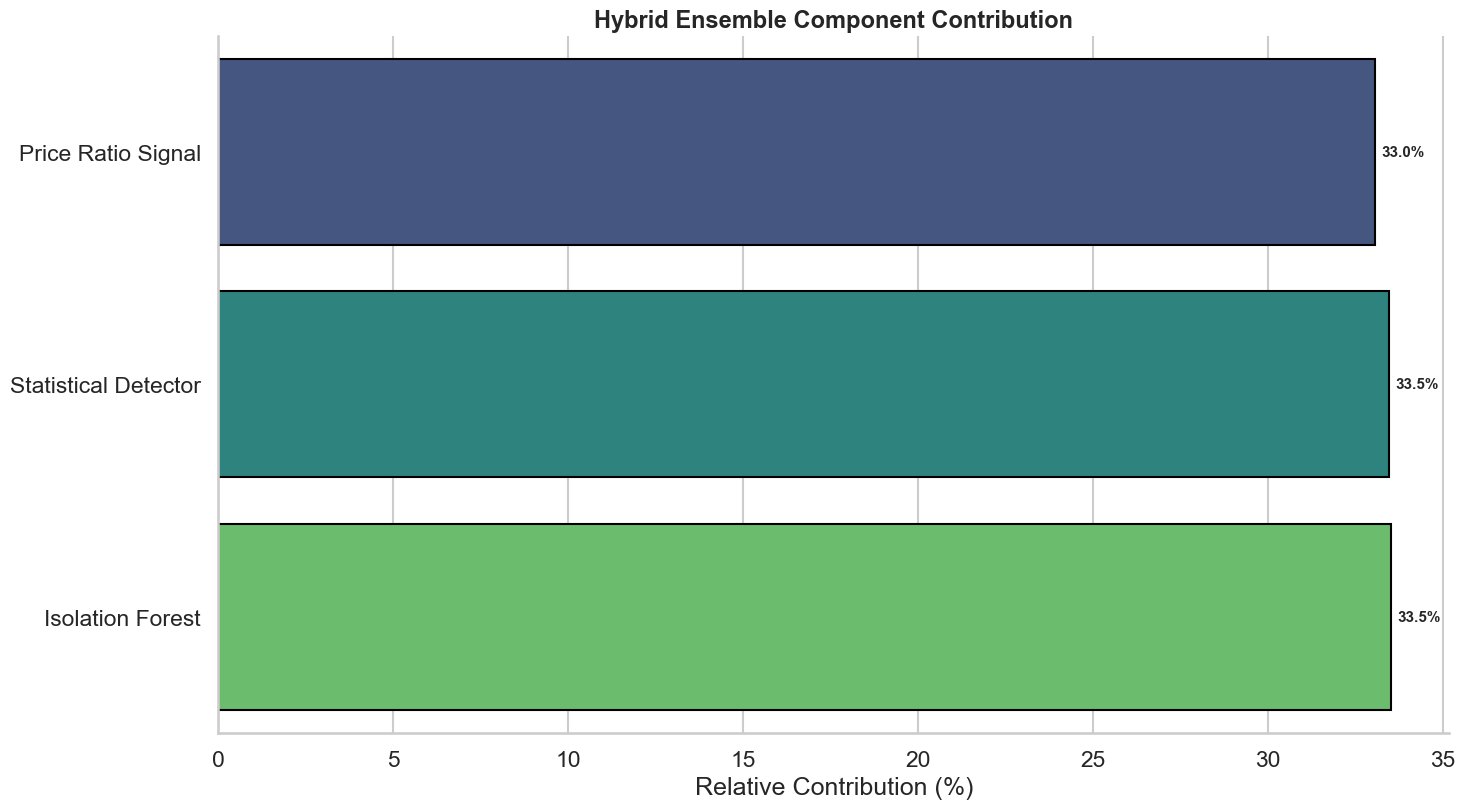

In [67]:
# ───────────────────────────────────────────────────────────────────────────
# Example — explain the single highest-risk transaction
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
idx = df["ensemble_score"].idxmax()
contribution = explain_transaction(idx)

plot_df = pd.DataFrame(
    contribution.items(), columns=["Component", "Contribution"]
).sort_values("Contribution", ascending=True)

ax = sns.barplot(
    data=plot_df, x="Contribution", y="Component", palette="viridis", edgecolor="black"
)
for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.1f}%",
        (p.get_width(), p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=11,
        fontweight="bold",
    )
plt.title("Hybrid Ensemble Component Contribution", fontsize=17, fontweight="bold")
plt.xlabel("Relative Contribution (%)")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

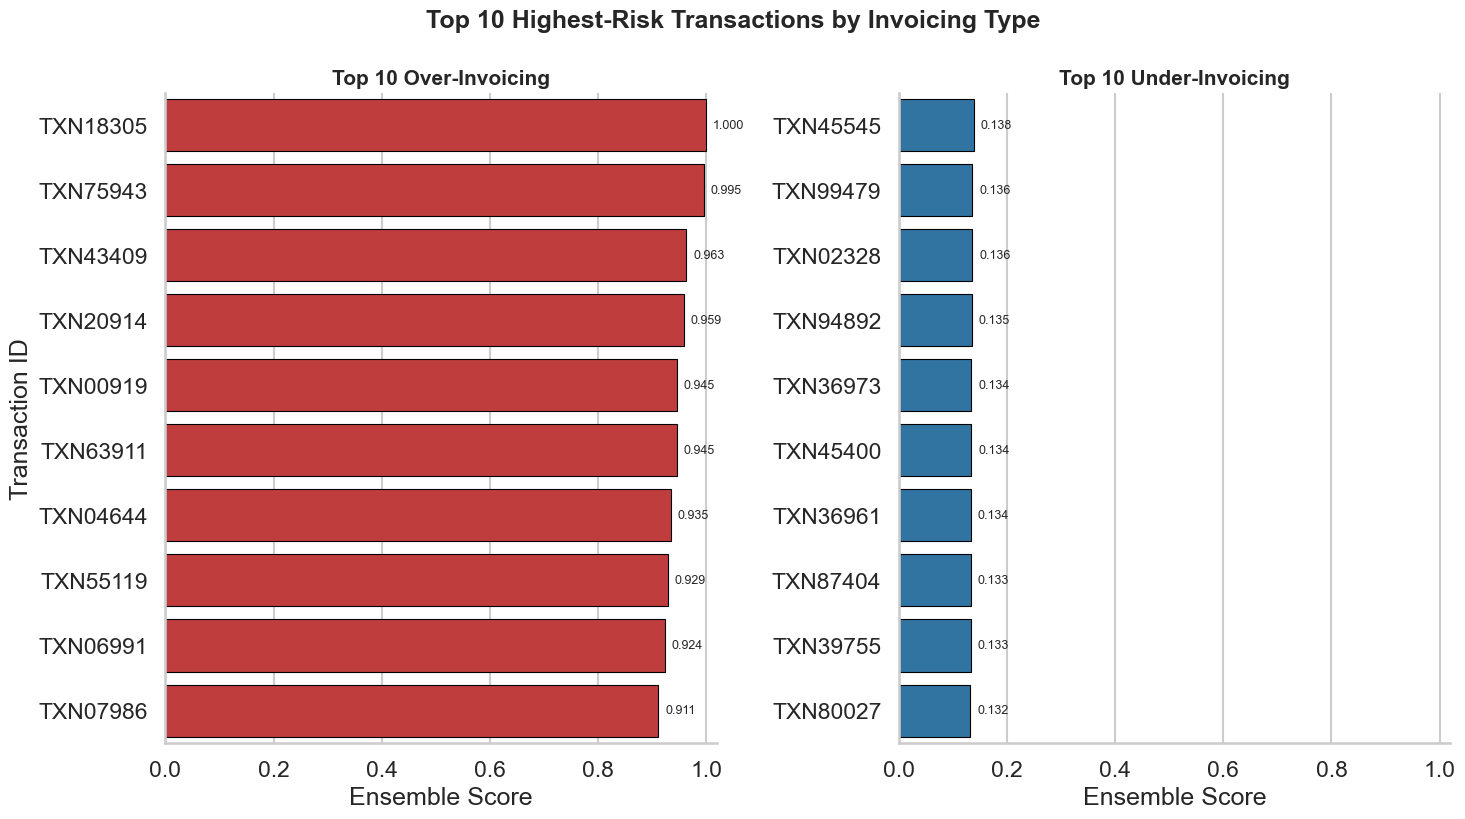

In [70]:
# ───────────────────────────────────────────────────────────────────────────
# BI 1 — Top 10 Over & Under Invoicing Transactions
# ───────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 15 * 9 / 16), sharex=True)

# Top 10 OVER_INVOICING
top_over = (
    df[df["predicted_direction"] == "OVER_INVOICING"]
    .sort_values("ensemble_score", ascending=False)
    .head(10)
)

# Top 10 UNDER_INVOICING
top_under = (
    df[df["predicted_direction"] == "UNDER_INVOICING"]
    .sort_values("ensemble_score", ascending=False)
    .head(10)
)

# ───────── Left Plot: Over Invoicing ─────────
sns.barplot(
    data=top_over,
    y="txn_id",
    x="ensemble_score",
    color="#D62728",
    edgecolor="black",
    linewidth=0.8,
    ax=axes[0],
)

axes[0].set_title("Top 10 Over-Invoicing", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Ensemble Score")
axes[0].set_ylabel("Transaction ID")
axes[0].set_xlim(0, 1.02)

for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(
        f"{width:.3f}",
        (width, p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
    )

# ───────── Right Plot: Under Invoicing ─────────
sns.barplot(
    data=top_under,
    y="txn_id",
    x="ensemble_score",
    color="#1F77B4",
    edgecolor="black",
    linewidth=0.8,
    ax=axes[1],
)

axes[1].set_title("Top 10 Under-Invoicing", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Ensemble Score")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1.02)

for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(
        f"{width:.3f}",
        (width, p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
    )

fig.suptitle(
    "Top 10 Highest-Risk Transactions by Invoicing Type",
    fontsize=18,
    fontweight="bold",
)

sns.despine()
plt.tight_layout()
plt.show()

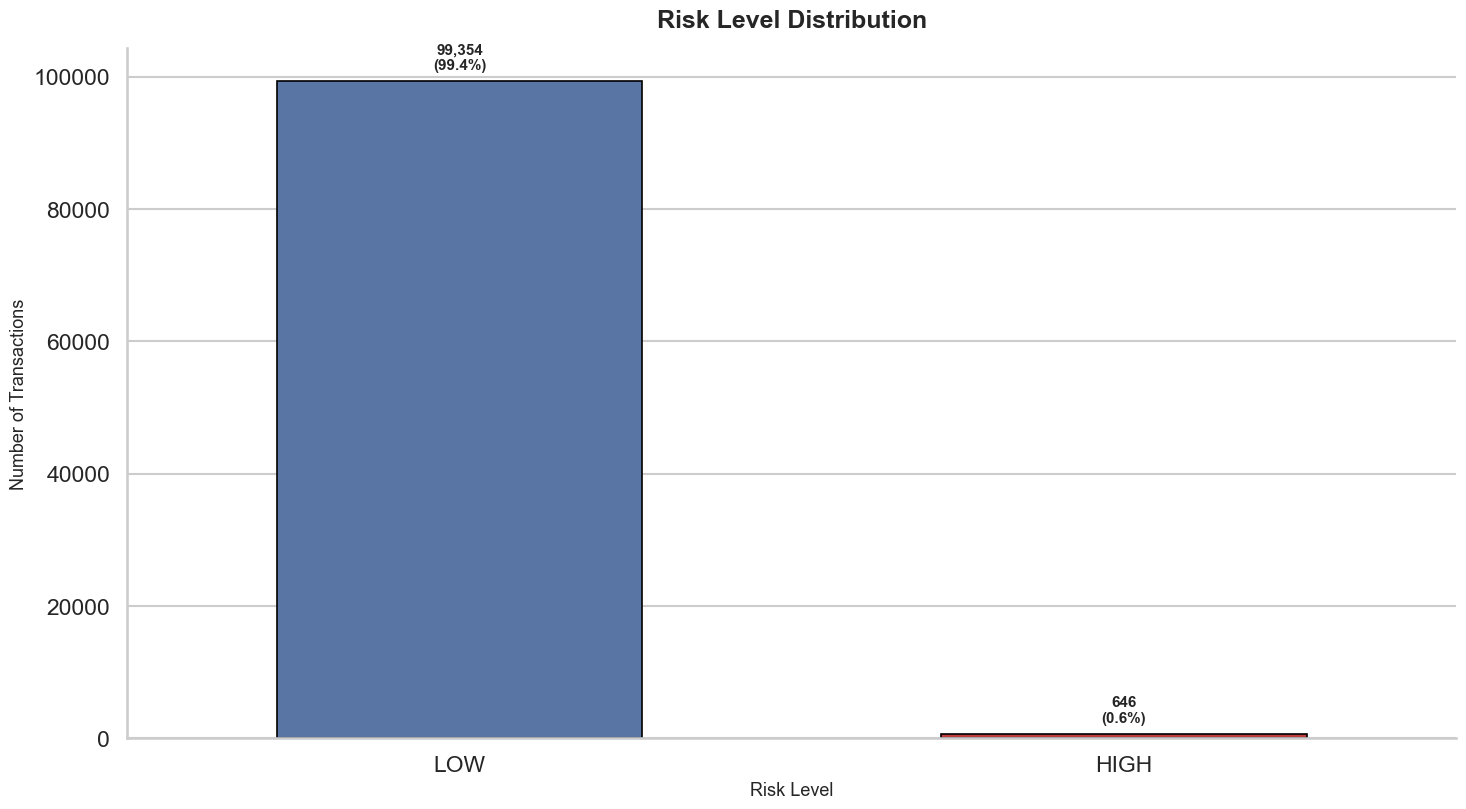

In [71]:
# ───────────────────────────────────────────────────────────────────────────
# BI 2 — Risk Level Distribution
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
ax = sns.countplot(
    data=df,
    x="risk_level",
    order=["LOW", "HIGH"],
    palette=["#4C72B0", "#D62728"],
    edgecolor="black",
    linewidth=1.2,
    width=0.55,
)
plt.title("Risk Level Distribution", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Risk Level", fontsize=13)
plt.ylabel("Number of Transactions", fontsize=13)

total_n = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percent = count / total_n * 100
    ax.annotate(
        f"{count:,}\n({percent:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        xytext=(0, 6),
        textcoords="offset points",
    )
sns.despine()
plt.tight_layout()
plt.show()

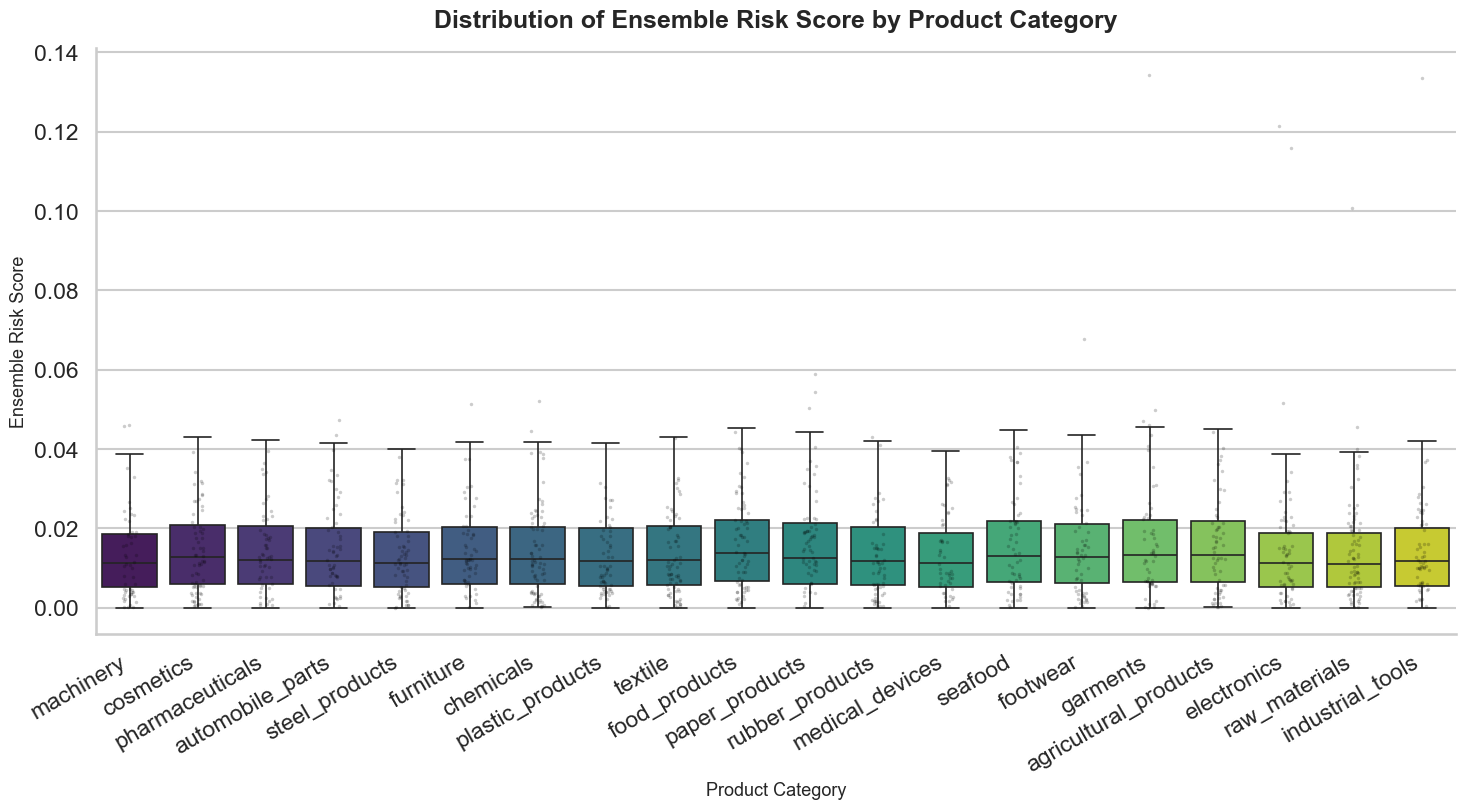

In [72]:
# ───────────────────────────────────────────────────────────────────────────
# BI 3 — Risk Score Distribution by Product Group
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
ax = sns.boxplot(
    data=df,
    x="product_group",
    y="ensemble_score",
    palette="viridis",
    showfliers=False,
    linewidth=1.2,
)
sns.stripplot(
    data=df.sample(min(1200, len(df)), random_state=RANDOM_SEED),
    x="product_group",
    y="ensemble_score",
    color="black",
    alpha=0.20,
    size=2.5,
)
plt.title(
    "Distribution of Ensemble Risk Score by Product Category",
    fontsize=18,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Product Category", fontsize=13)
plt.ylabel("Ensemble Risk Score", fontsize=13)
plt.xticks(rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

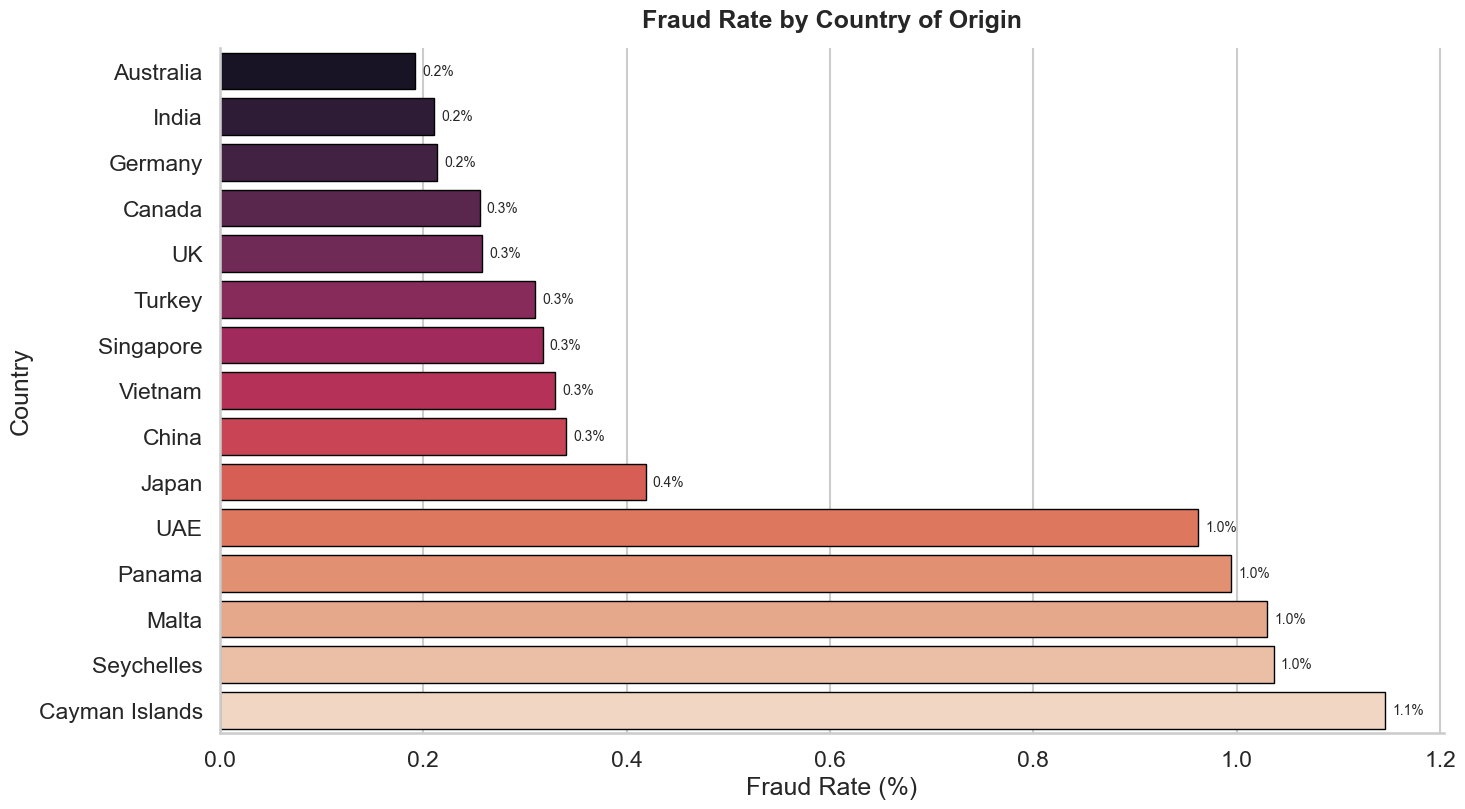

In [73]:
# ───────────────────────────────────────────────────────────────────────────
# BI 4 — Fraud Rate by Country of Origin
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
country_fraud = (
    df.groupby("country_origin")["anomaly_label"]
    .mean()
    .mul(100)
    .sort_values()
    .reset_index(name="Fraud Rate")
)

ax = sns.barplot(
    data=country_fraud,
    x="Fraud Rate",
    y="country_origin",
    palette="rocket",
    edgecolor="black",
    linewidth=1,
)
for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.1f}%",
        (p.get_width(), p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
    )
plt.title("Fraud Rate by Country of Origin", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Country")
sns.despine()
plt.tight_layout()
plt.show()

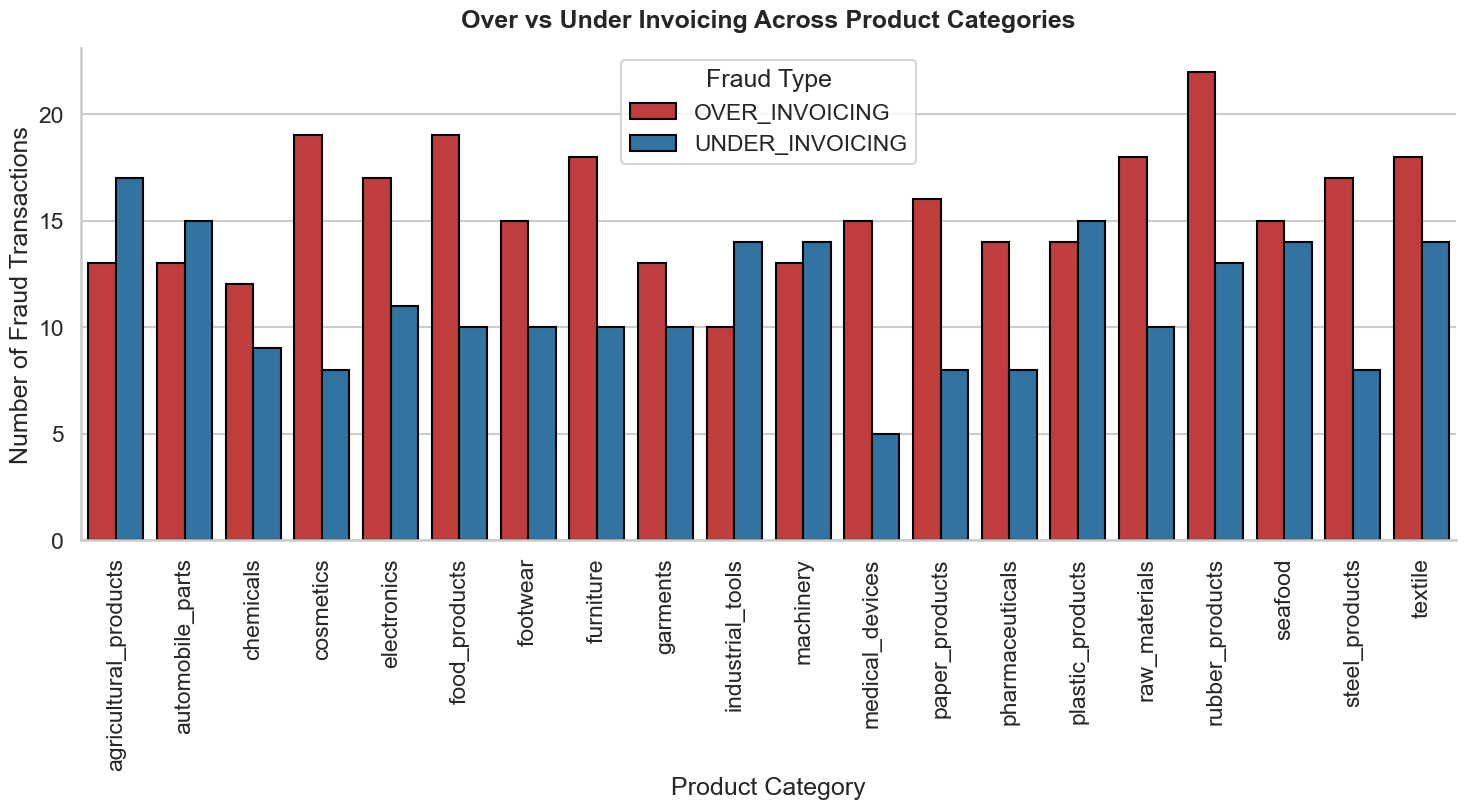

In [75]:
# ───────────────────────────────────────────────────────────────────────────
# BI 5 — Over vs Under Invoicing Across Product Categories
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 15 * 9 / 16))
direction_df = (
    df[df["true_direction"] != "NORMAL"]
    .groupby(["product_group", "true_direction"])
    .size()
    .reset_index(name="Count")
)

ax = sns.barplot(
    data=direction_df,
    x="product_group",
    y="Count",
    hue="true_direction",
    palette={"OVER_INVOICING": "#D62728", "UNDER_INVOICING": "#1F77B4"},
    edgecolor="black",
)
plt.title(
    "Over vs Under Invoicing Across Product Categories",
    fontsize=18,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Product Category")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(rotation=90)
plt.legend(title="Fraud Type")
sns.despine()
plt.tight_layout()
plt.show()

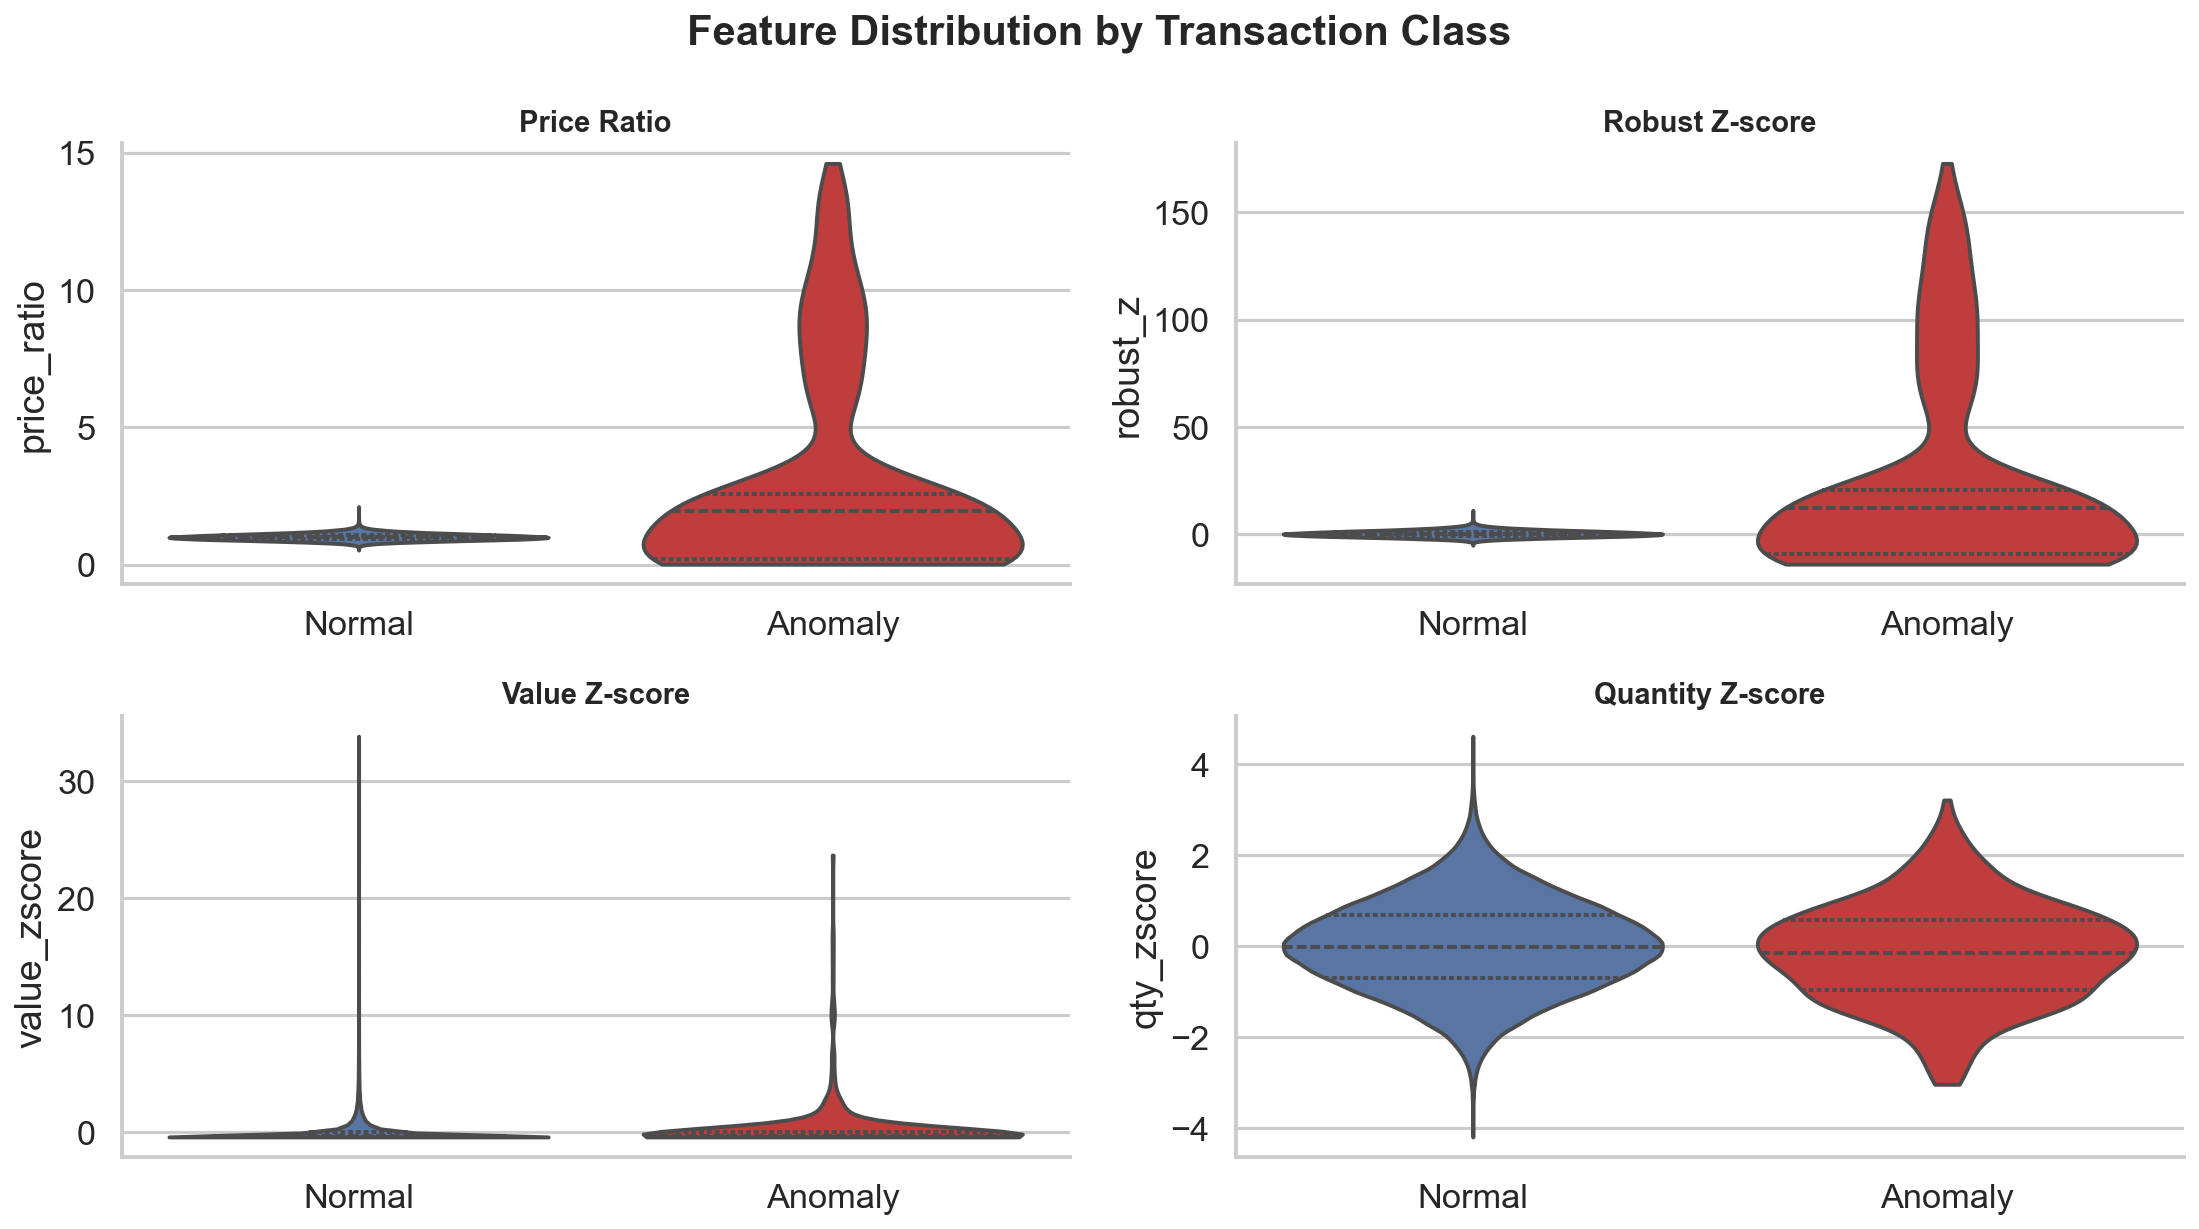

In [77]:
# ───────────────────────────────────────────────────────────────────────────
# BI 6 — Feature Distribution by Transaction Class
# ───────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 15 * 9 / 16), dpi=150)

plots = [
    ("price_ratio", "Price Ratio"),
    ("robust_z", "Robust Z-score"),
    ("value_zscore", "Value Z-score"),
    ("qty_zscore", "Quantity Z-score"),
]

for ax, (feature, title) in zip(axes.flat, plots):
    sns.violinplot(
        data=df,
        x="anomaly_label",
        y=feature,
        palette=["#4C72B0", "#D62728"],
        inner="quartile",
        cut=0,
        ax=ax,
    )
    ax.set_xticklabels(["Normal", "Anomaly"])
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(feature)

sns.despine()
plt.suptitle(
    "Feature Distribution by Transaction Class", fontsize=20, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [48]:
# ═══════════════════════════════════════════════════════════════════════════
#  Interactive Widget — Manual Transaction Predictor
# ═══════════════════════════════════════════════════════════════════════════

import ipywidgets as widgets
from IPython.display import display, clear_output

product_widget = widgets.Dropdown(
    options=sorted(PRODUCT_CATEGORIES.keys()), description="Product"
)
country_widget = widgets.Dropdown(options=ALL_COUNTRIES, description="Country")
qty_widget = widgets.IntText(value=100, description="Quantity")
price_widget = widgets.FloatText(value=500, description="Unit Price")
importer_widget = widgets.IntText(value=10, description="Importer Freq")
predict_btn = widgets.Button(
    description="Predict", button_style="success", icon="check"
)
output = widgets.Output()

In [49]:
def predict_transaction(_):
    with output:
        clear_output()

        product = product_widget.value
        quantity = qty_widget.value
        unit_price = price_widget.value
        country = country_widget.value
        importer = importer_widget.value
        hs_code = HS_CODE_MAP.get(product)

        if hs_code is None or hs_code not in peer_median_map:
            print("Invalid product / missing hs_code mapping")
            return

        peer = peer_median_map[hs_code]
        mad = peer_mad_map[hs_code]
        robust_z = (unit_price - peer) / (mad + 1e-9)
        abs_z = abs(robust_z)
        price_ratio = unit_price / peer
        log_ratio = np.log1p(abs(price_ratio - 1))
        declared_value = quantity * unit_price
        value_z = (declared_value - value_mean) / value_std
        qty_z = (np.log1p(quantity) - qty_mean) / qty_std
        country_risk = int(country in HIGH_RISK_COUNTRIES)

        sample = pd.DataFrame(
            {
                "robust_z": [robust_z],
                "value_zscore": [value_z],
                "qty_zscore": [qty_z],
                "importer_freq": [importer],
                "country_risk": [country_risk],
            }
        )

        X = scaler.transform(sample)
        iso_raw = -best_iso_forest.decision_function(X)[0]

        iso = min_max_scale_with_bounds(iso_raw, ISO_RAW_MIN, ISO_RAW_MAX)
        stat = min_max_scale_with_bounds(abs_z, STAT_RAW_MIN, STAT_RAW_MAX)
        ratio = min_max_scale_with_bounds(log_ratio, RATIO_RAW_MIN, RATIO_RAW_MAX)

        score = np.clip(stat**a_opt * iso**b_opt * ratio**c_opt, 0, 1)
        risk = "HIGH RISK" if score >= best_thr else "LOW RISK"

        direction = "NORMAL"
        if robust_z > Z_THRESHOLD:
            direction = "OVER INVOICING"
        elif robust_z < -Z_THRESHOLD:
            direction = "UNDER INVOICING"

        print("=" * 70)
        print("TBML MANUAL DETECTION (Demo Only)")
        print("=" * 70)
        print(f"Risk Score        : {score:.3f}")
        print(f"Prediction        : {risk}")
        print(f"Direction         : {direction}")
        print(f"Price Ratio       : {price_ratio:.2f}")
        print(f"Robust Z-score    : {robust_z:.2f}")
        print("=" * 70)

        components = {
            "Statistical": stat**a_opt,
            "Isolation Forest": iso**b_opt,
            "Price Ratio": ratio**c_opt,
        }
        total = sum(components.values())
        explain_pct = {k: 100 * v / total for k, v in components.items()}
        plot_df = pd.DataFrame(
            explain_pct.items(), columns=["Component", "Contribution"]
        ).sort_values("Contribution")

        plt.figure(figsize=(8, 4))
        ax = sns.barplot(
            data=plot_df, x="Contribution", y="Component", palette="viridis"
        )
        for p in ax.patches:
            ax.annotate(
                f"{p.get_width():.1f}%",
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0),
                textcoords="offset points",
                va="center",
            )
        plt.title("Detector Contribution")
        plt.show()

        print("\nBusiness Explanation")
        if price_ratio > 1.5:
            print("✔ Unit price significantly above peer median.")
        elif price_ratio < 0.7:
            print("✔ Unit price significantly below peer median.")
        if abs_z > Z_THRESHOLD:
            print("✔ Statistical deviation detected.")
        if country_risk:
            print("✔ High-risk trade corridor.")
        if importer <= 5:
            print("✔ Rare importer activity.")
        if (
            risk == "LOW RISK"
            and abs_z <= Z_THRESHOLD
            and 0.7 <= price_ratio <= 1.5
            and not country_risk
            and importer > 5
        ):
            print("✔ No major suspicious indicators detected.")


predict_btn.on_click(predict_transaction)
display(
    widgets.VBox(
        [
            product_widget,
            country_widget,
            qty_widget,
            price_widget,
            importer_widget,
            predict_btn,
            output,
        ]
    )
)